# Simulation of 'DNA chains on a substrate imaged via AFM'
**This notebook provides a complete example of generating a dataset of simulated DNA chains relxed on a substrate imaged via AFM.**

- **Output1:** synthetic AFM-like height images (optionally with `blank.spm` noise texture or simulated noise texture)
- **Output2:** DNA vs background mask (polyline from final bead coordinates, lightly dilated for better training)
- **Output3:** crossing mask (polyline intersection detection + Gaussian/chain-biased target)

Outputs are written to `OUT_DIR/` as `.npy` plus `manifest.csv` (which documents the user inputs used to create the images and masks).

>
---
**Cell execution order:** run cells 1 → 12 in sequence.  
Cells 1–9 define functions and globals. Cell 10 is the sanity check. Cell 11 is used for benchmarking the time for execution and generation of the dataset. Cell 12 generates the full dataset.

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)]()


# 1. **Imports and global settings**
## 1.1. Imports

First we import all the libraries that will be necessary for simulation of the images. If you plan to use molecular dynamics for the generation of the DNA chains, then please import the molecular dynamics libraries as well.

In [2]:
# Install dependencies (uncomment in a fresh environment / Colab)
# !pip cache purge

!pip install -q scipy matplotlib pillow
!pip install openmm[cuda13]                                    #change the cuda version depending on the CUDA version available on your system.


import os
from pathlib import Path
import re
import csv
import traceback
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import animation
from IPython.display import HTML, display

# Molecular dynamics
import openmm
import openmm.unit as unit

# Image processing
from scipy.ndimage import (
    gaussian_filter, grey_dilation, distance_transform_edt,
    binary_dilation, median_filter, affine_transform
)



#1.2 Defining the variables
Here we define the variables that will be used for the generation of the images and the masks. The variables control how the images and their masks will appear at the end. For training a Machine learning network like a U-Net, all images need to be of a standard size and need reproducible properties. To generate the likeness of DNA chains from simulated data, we start with building a chain by using a random walk in 3D with some set parameters like number of beads, bond length and persistence bonds and to simulate chain relaxation on substrate we raise the chain to a certain height.

In [ ]:
# ─────────────────────────────────────────────
# Global settings  (these are the variables that need to be changed to change the appearance of the resulting images)
# ─────────────────────────────────────────────

# Dataset
OUT_DIR       = "dna_dataset_1000_4lengths" # Name of the output directory that you would like to store your images and masks in
N_SAMPLES     = 1000                        # Number of samples that will be generated
BASE_SEED     = 0                           # Seed for reproducibility

# Image resolution (keep fixed for U-Net)
NX = 512
NY = 512

# Ring + MD
N_BEADS          = 90                  # default bead count for vizualization
BEAD_COUNTS      = [70, 80, 90, 100]   # four chain lengths
BOND_LENGTH      = 1.0                 # distance between beads
PERSISTENCE_BONDS = 23.0               # used to determine the range of angles which the chain is allowed to turn
BASE_Z           = 5.0                 # Height above the substrate that the chain starts at before relaxing
ANGLE_STIFNESS_MULT = 0.6

# MD recording
N_FRAMES         = 200
STEPS_PER_FRAME  = 200                 # Between every frame local energy minimization happens for the given number of steps

# AFM rendering
AFM_KW = dict(
    nx=NX, ny=NY,
    dna_diameter_nm=2.0,               # mapping to physical values
    tip_radius_nm=0.01,                # Radius of tip (modelled as hemishpere for convolution)
    max_height_nm=6.0,                 # Maximum height for the colorbar
    target_nm_per_px=0.08,             # Matching pixels to size of chain
    max_radius_px=96,                  # following parameters are used for improving the visualization of the chain
    radius_shrink_px=2.0,
    final_blur_sigma_px=0.20,
    apply_edge_taper=True,
    taper_sigma_nm=0.45,
    taper_floor=0.10,
    add_center_ridge=True,
    ridge_sigma_nm=0.25,
    ridge_amp_nm=0.25,
    grain_nm=0.0,
    grain_sigma_px=0.6,
    enable_crossing_boost=True,        # To boost the height of the crossings
    min_separation_beads=12,           # Distance to other chain segments to not boost indiscriminately
    boost_window_beads=2,              # How many beads to boost the height for
    guaranteed_offset_nm=1.0,          # How much to boost
    boost_method="additive",           # add to the height of beads being boosted
    boost_profile="gaussian",          # Height increase profile
    boost_sigma_beads=None,
    far_clip_nm=2.5,                   # Clip bead heights for beads that are not part of a crossing
    far_clip_window_beads=3,           # How many beads to clip the height for
    return_crossing_info=True,         # To ensure that mask information is passed to other functions. Change to False if masks are not needed
    return_masks=True,
)

# DNA mask
DNA_MASK_DILATE_PX = 3                 # Dilation of mask for better training

# Crossing mask
CROSS_MIN_SEP_BEADS   = 12             # Where to stop for the crossing calculation
CROSS_SIGMA_CENTER_PX = 5.0            # How many pixels make us the center of a crossing
CROSS_SIGMA_PERP_PX   = 1.8            # Crossing coloring parameter (how many pixels to modulate for the crossing)
CROSS_CHAIN_EXTENT    = 5.0            # For the chain weighting of the mask
CROSS_CENTER_WEIGHT   = 1.7            # For the chain weighting of the mask (chain-weighted guassian)
CROSS_CHAIN_WEIGHT    = 0.9
CROSS_CLIP_TO_DNA_MASK = True

#1.3 Noise
To add realistic noise to the images so that they closely resemble real AFM images, 2 options have been provided in this notebook.


1. For users that have access to AFM imaging setups and substrates, a **blank ``.spm``** file can be loaded into this enviroment. The notebook will parse through the file and add the noise that would appear as if a DNA chain were imaged on that substrate, thus making the output dataset closer to real DNA if it were to be imaged on that setup and substrate.
2. For users that do not have access to AFM imaging setups or available blanks, noise can be generated through an ensemble of blanks that were imaged on nickel susbtrates and processed. The information of that noise is available as a Power spectral density noise model that is available in this repository. There are 3 noise synthesis models offered but *mean_full2d* is preferred and chosen as the default.



In [ ]:
#Noise
TARGET_NOISE_RMS_NM   = 0.19           # This variable controls the height of the noise in nanometers and this is added to the final image


# Blank SPM noise
USE_BLANK_SPM_NOISE   = True
BLANK_SPM_PATH        = "/content/20240411_blank_water.0_00000.spm"  # optional; if missing/invalid, PSD fallback noise is used


# PSD-model fallback noise (used when no blank .spm file is available)
USE_PSD_NOISE_FALLBACK = True
MODEL_PATH             = "/content/psd_noise_model.npz"
PSD_NOISE_METHOD       = "mean_full2d"    # or "lognormal_full2d" / "empirical_radial"
PSD_NOISE_STD_SCALE    = 2.0

#Checking if output directory will be created
os.makedirs(OUT_DIR, exist_ok=True)
for _sub in ["images", "dna_masks", "cross_masks", "meta"]:
    os.makedirs(os.path.join(OUT_DIR, _sub), exist_ok=True)

print("Output folder:", os.path.abspath(OUT_DIR))

## 2. Chain Creation (3-D Persistent Random Walk)
Now we start with creating the DNA chain.

The function `make_tangled_ring_initial` builds a closed polymer ring via a persistent random walk and enforces ring-closure.

A 3-D plot is shown at the end of the cell so you can inspect the initial geometry immediately.

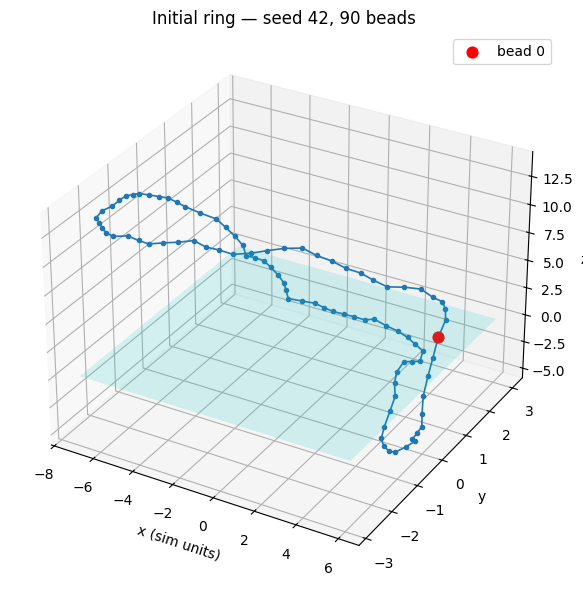

In [27]:
def make_tangled_ring_initial(
    seed,
    n_beads=N_BEADS,
    bond_length=BOND_LENGTH,
    persistence_bonds=PERSISTENCE_BONDS,
    base_z=BASE_Z,
):
    """
    Generates a closed (ring) polymer with a persistent random-walk tangent.
    Each step rotates the current direction by a small random angle around a
    perpendicular axis.  Ring closure is enforced by linearly distributing
    the end-to-end gap across all beads. The chain is then lifted to base_z
    so it can relax down to the z=0 substrate during MD.
    """
    rng = np.random.default_rng(int(seed))

    steps = np.zeros((n_beads, 3), dtype=np.float32)
    vec   = np.array([1.0, 0.0, 0.0], dtype=np.float32)                     #Initialization of vector for chain propogation

    for k in range(n_beads):
        dtheta = rng.normal(scale=np.sqrt(1.0 / persistence_bonds))
        axis   = rng.normal(size=3).astype(np.float32)                      #choose an axis at random for chain propogation in 3D
        axis  -= axis.dot(vec) * vec                                        # remove component along vec
        axis_norm = np.linalg.norm(axis)
        if axis_norm < 1e-8:
            axis      = np.array([0.0, 0.0, 1.0], dtype=np.float32)
            axis_norm = 1.0
        axis /= axis_norm
        vec   = vec * np.cos(dtheta) + np.cross(axis, vec) * np.sin(dtheta) # Calculating vector for chain propogation
        vec  /= np.linalg.norm(vec)
        steps[k] = bond_length * vec

    coords = np.cumsum(steps, axis=0)                                       # Coordinates for open chain

    # Enforce ring closure
    closure_error = coords[-1] - coords[0]
    t      = np.linspace(0, 1, n_beads, dtype=np.float32).reshape(-1, 1)    # Based on the distance between first and last bead a closure error is propogated to all bead positions to form a closed chain
    coords -= t * closure_error
    coords -= coords.mean(axis=0)                                           # This method works better than directing the chain to go away and then come back to original position

    # Lift above substrate
    coords[:, 2] += float(base_z)                                           # Changing z values to lift the chain off the substrate
    return coords.astype(np.float32)


# ── Quick visualisation ──────────────────────────────────────────────────────
_demo_coords = make_tangled_ring_initial(seed=43)
_cc = np.vstack([_demo_coords, _demo_coords[0]])                            # close the ring for plotting

fig = plt.figure(figsize=(7, 6))
ax  = fig.add_subplot(111, projection="3d")
ax.plot(_cc[:, 0], _cc[:, 1], _cc[:, 2], "-o", markersize=3, linewidth=1.2)
ax.scatter(_cc[0, 0], _cc[0, 1], _cc[0, 2], color="red", s=60, zorder=5, label="bead 0")

# Draw substrate plane
_xs = np.linspace(_cc[:, 0].min(), _cc[:, 0].max(), 2)
_ys = np.linspace(_cc[:, 1].min(), _cc[:, 1].max(), 2)
_X, _Y = np.meshgrid(_xs, _ys)
ax.plot_surface(_X, _Y, np.zeros_like(_X), alpha=0.15, color="cyan")

ax.set_xlabel("x (sim units)"); ax.set_ylabel("y"); ax.set_zlabel("z")
ax.set_title(f"Initial ring — seed 42, {len(_demo_coords)} beads")
ax.legend()
plt.tight_layout()
plt.show()

## 3. Molecular Dynamics Relaxation
To accurately mimic chain relaxation on a susbstrate a coarse grained molecular dynamics simulation is performed using OpenMM (no water or other molecules simulated)

The function `run_md_relaxation` runs a Langevin-dynamics simulation in the overdampled regime via OpenMM.
Here we have added:

1. Harmonic bonds
2. Bending-angle stiffness
3. A surface-attraction to cause chain relaxation
4. A hard-wall force to keep chain above substrate
5. A short-range WCA repulsion to ensure chain does not take non physical configurations

The function then records `n_frames` snapshots which can be used for visualization.

We start with testing the OpenMM installation (can be tricky at times)

In [28]:
## Test the OpenMM installation before running the following cell to ensure that GPU acceleration will work
import openmm
import openmm.testInstallation

# Run the standard OpenMM installation test to check for CUDA/GPU support
try:
    openmm.testInstallation.main()
except Exception as e:
    print(f"Test failed: {e}")


OpenMM Version: 8.5
Git Revision: b55e60882dffcddb2532cceda4201c0fdc9ec2d5

There are 4 Platforms available:

1 Reference - Successfully computed forces
2 CPU - Successfully computed forces
3 CUDA - Error computing forces with CUDA platform
4 OpenCL - Successfully computed forces

CUDA platform error: Error loading CUDA module: CUDA_ERROR_UNSUPPORTED_PTX_VERSION (222)

Median difference in forces between platforms:

Reference vs. CPU: 6.29855e-06
Reference vs. OpenCL: 6.74321e-06
CPU vs. OpenCL: 7.92708e-07

All differences are within tolerance.


And then once we are sure that OpenMM is correctly installed we run the MD functions

In [29]:
def run_md_relaxation(coords0, seed,
                      n_frames=N_FRAMES, steps_per_frame=STEPS_PER_FRAME):
    """
    Takes initial bead coordinates and runs Langevin dynamics (pure OpenMM).

    Forces applied:
    - Harmonic bonds + angle stiffness along the ring
    - Surface attraction (linear in z) + hard wall at z = 0
    - Short-range WCA repulsion between non-bonded beads

    Returns a list of (n_beads, 3) coordinate arrays (n_frames + 1 entries;
    frame 0 is the pre-minimisation geometry).
    """
    coords0 = np.asarray(coords0, dtype=np.float32)
    n       = int(coords0.shape[0])

    extent = (coords0.max(axis=0) - coords0.min(axis=0)).max()                  # how big the bounding box for the molecular dynamics needs to be
    box    = float(extent + 10.0)

    # ── Reduced-unit constants (matches polychrom temperature=1 convention) ──
    # All lengths in nm, energies in kJ/mol.
    BOLTZ_kJmol    = 0.00831445   # kJ / (mol · K)
    temperature    = 1.0          # K  (reduced; sets energy scale kT ≈ 0.0083 kJ/mol)
    kT             = BOLTZ_kJmol * temperature   # kJ/mol
    conlen         = 1.0          # nm
    mass_amu       = 100.0        # Da per bead
    collision_rate = 0.6          # ps⁻¹
    error_tol      = 0.005

    # ── Build system ─────────────────────────────────────────────────────────
    system = openmm.System()
    system.setDefaultPeriodicBoxVectors(
        openmm.Vec3(box, 0, 0),
        openmm.Vec3(0, box, 0),
        openmm.Vec3(0, 0, box),
    )
    for _ in range(n):
        system.addParticle(mass_amu)

    # Remove COM drift — applied every 100 steps
    system.addForce(openmm.CMMotionRemover(100))                                # To ensure CPU and GPU calculation are consistent (since GPU minimizations calculations can suffer from drift)

    # ── 1. Harmonic bonds ────────────────────────────────────────────────────
    # Polychrom convention: E = kT / (2·wiggle²) · (r − L)²
    # OpenMM HarmonicBondForce: E = (k/2)·(r − r0)²  →  k = kT / wiggle²
    bond_L = 1.0   # nm
    wiggle = 0.1   # nm  (bondWiggleDistance)
    k_bond = kT / (wiggle ** 2)   # kJ/mol/nm²

    bond_force = openmm.HarmonicBondForce()
    bond_force.setUsesPeriodicBoundaryConditions(True)
    for i in range(n):
        bond_force.addBond(i, (i + 1) % n, bond_L, k_bond)
    system.addForce(bond_force)

    # ── 2. Bending (angle) stiffness ─────────────────────────────────────────
    # E = kT · k_angle · (1 − cos(θ − π))  — equilibrium at θ = π (straight)
    k_angle     = 12.0
    angle_force = openmm.CustomAngleForce(
        "kT * kangle * (1 - cos(theta - 3.141592653589793))"
    )
    angle_force.addGlobalParameter("kT",     kT)
    angle_force.addGlobalParameter("kangle", k_angle)
    for i in range(n):
        angle_force.addAngle((i - 1) % n, i, (i + 1) % n, [])
    system.addForce(angle_force)

    # ── 3. Surface: linear attraction (z > 0) + harmonic hard wall (z < 0) ──
    wall_expr = (
        "kT * ("
        "  F_pull * z * step(z) + "
        "  0.5 * wallK * (z^2) * step(-z)"
        ")"
    )
    wall_force = openmm.CustomExternalForce(wall_expr)
    wall_force.addGlobalParameter("kT",     kT)
    wall_force.addGlobalParameter("F_pull", 9.0)
    wall_force.addGlobalParameter("wallK",  100.0)
    for i in range(n):
        wall_force.addParticle(i, [])
    system.addForce(wall_force)

    # ── 4. WCA repulsion (repulsion between non-bonded pairs only) ──────────────────────────────
    rep_sigma  = 1.4 * conlen   # nm
    rep_cutoff = 2.3 * conlen   # nm
    rep_expr   = (
        "4*eps*((sig/r)^12 - (sig/r)^6 + 0.25) * step(cutoff - r); "
        "cutoff = 2^(1.0/6.0) * sig"
    )
    rep_force = openmm.CustomNonbondedForce(rep_expr)
    rep_force.setNonbondedMethod(openmm.CustomNonbondedForce.CutoffPeriodic)
    rep_force.setCutoffDistance(rep_cutoff)
    rep_force.addGlobalParameter("eps", 1.7 * kT)
    rep_force.addGlobalParameter("sig", rep_sigma)
    for i in range(n):
        rep_force.addParticle([])
    for i in range(n):                        # exclude bonded neighbours
        rep_force.addExclusion(i, (i + 1) % n)
    system.addForce(rep_force)

    # ── Integrator ────────────────────────────────────────────────────────────
    integrator = openmm.VariableLangevinIntegrator(temperature, collision_rate, error_tol)
    integrator.setRandomNumberSeed(int(seed))

    # ── Platform selection: OpenCL → CPU fallback ─────────────────────────────
    context = None
    for platform_name in ("OpenCL", "CPU"):                                     # CUDA did not work on google colab, so using OpenCL here
        try:
            platform = openmm.Platform.getPlatformByName(platform_name)
            context  = openmm.Context(system, integrator, platform)
            print(f"Using {platform_name} platform.")
            break
        except openmm.OpenMMException as e:
            print(f"  {platform_name} unavailable: {e}")
        except Exception as e:
            print(f"  {platform_name} failed unexpectedly: {e}")

    if context is None:
        raise RuntimeError("No OpenMM platform could be initialised.")

    # ── Set initial positions and box ─────────────────────────────────────────
    positions = [
        openmm.Vec3(float(coords0[i, 0]), float(coords0[i, 1]), float(coords0[i, 2]))
        for i in range(n)
    ]
    context.setPositions(positions)
    context.setPeriodicBoxVectors(
        openmm.Vec3(box, 0, 0),
        openmm.Vec3(0, box, 0),
        openmm.Vec3(0, 0, box),
    )

    # Capture the true initial geometry before any minimisation (just in case the chain reaches substrate even before the 1st frame)
    frames = []
    state = context.getState(getPositions=True)
    pos   = state.getPositions(asNumpy=True).value_in_unit(unit.nanometer)
    frames.append(pos.copy())

    # Cap iterations so that extra compute is not used once chain relaxation is complete
    openmm.LocalEnergyMinimizer.minimize(context, tolerance=10, maxIterations=200)

    # ── Record frames ─────────────────────────────────────────────────────────
    for _ in range(int(n_frames)):
        integrator.step(int(steps_per_frame))
        state = context.getState(getPositions=True)
        pos   = state.getPositions(asNumpy=True).value_in_unit(unit.nanometer)
        frames.append(pos.copy())

    return frames   # n_frames + 1 entries (frame 0 = initial geometry)

##4. Non-MD chain generation
In case you would not like to use molecular dynamics to generate the chains, it is also possible to skip the molecular dynamics and just use a simple 2D persistent walk to generate the DNA chains. The chains generated by this method might have some non physical configurations but the propoerties of the function can be modulated to achieve desired results.

In [ ]:
def make_ring_2d_persistent_initial(
    seed,
    n_beads,
    bond_length=BOND_LENGTH,                  # From Cell 1
    persistence_bonds=PERSISTENCE_BONDS,      # From Cell 1
    angle_stiffness_mult=ANGLE_STIFNESS_MULT, # New parameter (only in Non-MD, defined in Cell 1)
    z_std=0.08,                               # Small Gaussian noise for Z
    base_z=0.2,                               # Low altitude for "deposited" look
    angle_limit=np.pi/2                       # Constraint to keep walk exploring
):
    """
    Generates a 2D persistent ring and returns it as a list of frames [ (N,3) ].
    Replaces both the initial generation and the MD relaxation cells.
    """
    rng = np.random.default_rng(int(seed))
    n = int(n_beads)

    # 1. Angular exploration
    sigma_dtheta = np.sqrt(2.0 / max(persistence_bonds, 1.0)) / max(angle_stiffness_mult, 1e-6) #Which angles are permissible for placements of the next bead

    theta0 = rng.uniform(0.0, 2.0 * np.pi)
    # Clipping the normal distribution implements the "angle constraint"
    dtheta = rng.normal(0.0, sigma_dtheta, size=n).astype(np.float64)
    dtheta = np.clip(dtheta, -angle_limit, angle_limit)
    thetas = theta0 + np.cumsum(dtheta)

    # 2. XY Coordinates
    bonds = np.stack([np.cos(thetas), np.sin(thetas)], axis=1) * float(bond_length)
    xy = np.zeros((n, 2), dtype=np.float64)
    xy[1:] = np.cumsum(bonds[:-1], axis=0)

    # 3. Seamless Closure Correction
    # Ensures the last bead connects back to the first with bond_length consistency
    end_error = (xy[-1] + bonds[-1]) - xy[0]
    t = (np.arange(n, dtype=np.float64) / n)[:, None]
    xy = xy - t * end_error
    xy -= xy.mean(axis=0) # Center at origin

    # 4. Assembly with Gaussian Z-noise
    coords = np.zeros((n, 3), dtype=np.float32)
    coords[:, 0] = xy[:, 0].astype(np.float32)
    coords[:, 1] = xy[:, 1].astype(np.float32)
    # Assign random small z values to simulate a deposited state
    coords[:, 2] = rng.normal(loc=base_z, scale=z_std, size=n).astype(np.float32)

    # Return as a list containing one frame to mimic run_md_relaxation output
    return [coords]

## 5. MD Animation
Now we can visulize the Molecular dynamics simulation to see how the relaxation has worked.

The function `show_md_animation` renders an interactive 3-D animation of MD frames in the notebook.
Running this cell will automatically generate and display the animation for a single deterministic chain (seed 0, default bead count).

In [1]:
def show_md_animation(frames, interval_ms=150):
    """
    Renders an in-notebook HTML5 animation of MD frames.
    Pure visualisation — does not mutate any arrays.
    """
    frames = [np.asarray(f, dtype=np.float32) for f in frames]
    all_coords = np.concatenate(frames, axis=0)
    mins = all_coords.min(axis=0) - 2
    maxs = all_coords.max(axis=0) + 2

    x_plane = np.linspace(mins[0], maxs[0], 2)
    y_plane = np.linspace(mins[1], maxs[1], 2)
    X_plane, Y_plane = np.meshgrid(x_plane, y_plane)
    Z_plane = np.zeros_like(X_plane)

    fig = plt.figure(figsize=(6, 6))
    ax  = fig.add_subplot(111, projection="3d")

    def init():
        ax.set_xlim(mins[0], maxs[0])
        ax.set_ylim(mins[1], maxs[1])
        ax.set_zlim(mins[2], maxs[2])
        ax.set_xlabel("x"); ax.set_ylabel("y"); ax.set_zlabel("z")
        return []

    def update(i):
        ax.cla()
        c  = frames[i]
        cc = np.vstack([c, c[0]])
        ax.plot(cc[:, 0], cc[:, 1], cc[:, 2], "-", linewidth=1)
        ax.scatter(c[:, 0], c[:, 1], c[:, 2], s=5)
        ax.plot_surface(X_plane, Y_plane, Z_plane, alpha=0.2)
        ax.set_xlim(mins[0], maxs[0])
        ax.set_ylim(mins[1], maxs[1])
        ax.set_zlim(mins[2], maxs[2])
        ax.set_xlabel("x"); ax.set_ylabel("y"); ax.set_zlabel("z")
        ax.set_title(f"Frame {i}/{len(frames)-1}")
        return []

    ani = animation.FuncAnimation(
        fig, update, frames=len(frames), init_func=init,
        interval=int(interval_ms), blit=False
    )
    plt.close(fig)
    display(HTML(ani.to_jshtml()))


# ── Run animation automatically (deterministic seed) ─────────────────────────
print("Generating initial ring and running MD (seed=0)…")
_anim_coords0 = make_tangled_ring_initial(seed=0)
_anim_frames  = run_md_relaxation(_anim_coords0, seed=0,
                                   n_frames=N_FRAMES,
                                   steps_per_frame=STEPS_PER_FRAME)
print(f"MD done — {len(_anim_frames)} frames.  Rendering animation…")
show_md_animation(_anim_frames)

Generating initial ring and running MD (seed=0)…


NameError: name 'make_tangled_ring_initial' is not defined

## 6. Height based AFM Rendering
Once we have the coordinates of the relaxed chain either via Molecular Dynamics or without, now we can start to convert the coordinates into a DNA chain as if it were imaged via AFM. We mimic tip convolution using a spherical tip to get the desired appearance.   

Here we define all the AFM rendering utilities. All functions described here are essential for getting the 'look' of the DNA chains. Function descriptions are added to the functions themselves. Information necessary to build the masks later on is also preserved in these functions.

In [30]:
# ─────────────────────────────────────────────────────────────────────────────
# Low-level geometry helpers
# ─────────────────────────────────────────────────────────────────────────────

def _seg_intersect_2d(p1, p2, q1, q2, eps=1e-12):
    """
    Strict 2-D segment intersection.
    Returns (hit, pt, t, u) where pt = p1 + t*(p2-p1) = q1 + u*(q2-q1).
    Returns (False, None, None, None) for parallel / collinear segments.
    """
    p1 = np.asarray(p1, dtype=float); p2 = np.asarray(p2, dtype=float)
    q1 = np.asarray(q1, dtype=float); q2 = np.asarray(q2, dtype=float)
    r   = p2 - p1;  s = q2 - q1
    rxs = r[0]*s[1] - r[1]*s[0]
    if abs(rxs) < eps:
        return False, None, None, None
    qp = q1 - p1
    t  = (qp[0]*s[1] - qp[1]*s[0]) / rxs
    u  = (qp[0]*r[1] - qp[1]*r[0]) / rxs
    if 0.0 <= t <= 1.0 and 0.0 <= u <= 1.0:
        return True, p1 + t*r, t, u
    return False, None, None, None


def _circ_sep(n, i, j):
    """Circular distance between bead indices on a ring of n beads."""
    d = abs(int(i) - int(j))
    return min(d, n - d)


# ─────────────────────────────────────────────────────────────────────────────
# Structuring-element / grid helpers
# ─────────────────────────────────────────────────────────────────────────────

def disk_footprint(r_px: float):
    """Boolean circular footprint of radius r_px pixels."""
    if r_px < 0.5:
        return np.ones((1, 1), dtype=bool)
    r = int(np.ceil(r_px))
    y, x = np.ogrid[-r:r+1, -r:r+1]
    return (x*x + y*y) <= r*r


def upsample_nn(a, out_shape):
    """Nearest-neighbour upsample array a to out_shape."""
    ny_out, nx_out = out_shape
    ny_in,  nx_in  = a.shape
    if (ny_out, nx_out) == (ny_in, nx_in):
        return a
    sy = max(ny_out // ny_in, 1)
    sx = max(nx_out // nx_in, 1)
    a_up = a.repeat(sy, axis=0).repeat(sx, axis=1)
    return a_up[:ny_out, :nx_out]


def choose_effective_grid(xmin, xmax, ymin, ymax, nx, ny,
                           target_nm_per_px=0.10):
    """
    If the physical pixel size is already coarser than target_nm_per_px,
    use the full grid directly.  Otherwise return a reduced grid that
    will be upsampled after rendering.
    """
    px = (xmax - xmin) / max(nx - 1, 1)
    py = (ymax - ymin) / max(ny - 1, 1)
    p  = 0.5 * (px + py)
    if p >= target_nm_per_px:
        return nx, ny, p
    factor  = int(np.ceil(target_nm_per_px / max(p, 1e-12)))
    nx_eff  = max(128, nx // factor)
    ny_eff  = max(128, ny // factor)
    px_eff  = (xmax - xmin) / max(nx_eff - 1, 1)
    return nx_eff, ny_eff, px_eff


def disk_cap_structure(radius_nm: float, p_nm_per_px: float,
                        max_radius_px=96):
    """
    Hemispherical-cap structuring element representing the DNA cross-section.
    Each pixel inside the disk gets a height equal to the spherical-cap height
    at that radial distance.
    """
    r_px = radius_nm / max(p_nm_per_px, 1e-12)
    R    = int(np.clip(np.ceil(r_px), 1, max_radius_px))
    y, x = np.ogrid[-R:R+1, -R:R+1]
    d2   = x*x + y*y
    inside = d2 <= (r_px * r_px)
    d_nm   = np.sqrt(d2).astype(np.float32) * np.float32(p_nm_per_px)
    structure = np.full((2*R+1, 2*R+1), -1e9, dtype=np.float32)
    structure[inside] = np.sqrt(
        np.maximum(radius_nm**2 - d_nm[inside]**2, 0.0)
    ).astype(np.float32)
    return inside.astype(bool), structure


def disk_sphere_structure(tip_radius_nm: float, p_nm_per_px: float,
                           max_radius_px=128):
    """
    Spherical-cap structuring element representing the AFM tip geometry.
    Used to convolve the surface with the tip shape.
    """
    Rpx = tip_radius_nm / max(p_nm_per_px, 1e-12)
    R   = int(np.clip(np.ceil(Rpx), 1, max_radius_px))
    y, x = np.ogrid[-R:R+1, -R:R+1]
    d2   = x*x + y*y
    inside = d2 <= (Rpx * Rpx)
    d_nm   = np.sqrt(d2).astype(np.float32) * np.float32(p_nm_per_px)
    structure = np.full((2*R+1, 2*R+1), -1e9, dtype=np.float32)
    structure[inside] = (
        np.sqrt(np.maximum(tip_radius_nm**2 - d_nm[inside]**2, 0.0))
        - tip_radius_nm
    ).astype(np.float32)
    return inside.astype(bool), structure


# ─────────────────────────────────────────────────────────────────────────────
# Crossing boost
# ─────────────────────────────────────────────────────────────────────────────

def _taper_weight(idx_off, w, profile="gaussian", sigma=None):
    """
    Smooth weight in [0, 1] used to fade the crossing height boost along
    the bead-index window of half-width w.

    profile:
      'gaussian'   — smooth dome (recommended)
      'hemisphere' — half-circle taper
      'linear'     — simple linear ramp
    """
    if w <= 0:
        return 1.0
    a = abs(idx_off)
    if profile == "linear":
        return 1.0 - (a / (w + 1.0))
    if profile == "hemisphere":
        x = a / (w + 1.0)
        return float(np.sqrt(max(0.0, 1.0 - x*x)))
    # gaussian (default)
    if sigma is None:
        sigma = max(1e-6, 0.5 * (w + 0.5))
    g     = float(np.exp(-(idx_off**2) / (2.0 * sigma**2)))
    g_end = float(np.exp(-(w**2)       / (2.0 * sigma**2)))
    if g_end < 0.999:
        g = float(np.clip((g - g_end) / (1.0 - g_end), 0.0, 1.0))
    return g


def _collect_intersections(xy_nm, min_separation_beads=12,
                            merge_radius_nm=0.5):
    """
    Brute-force all segment pairs of a closed ring polyline to find crossings.
    Skips adjacent/shared-vertex pairs and contour-nearby pairs.
    Clusters nearby raw hits via _merge_crossing_clusters.

    Returns list of dicts:
      {pt_nm, seg_i, seg_j, t, u, n_hits}
    """
    xy = np.asarray(xy_nm, dtype=float)
    n  = int(xy.shape[0])
    raw = []
    for i in range(n):
        i2   = (i + 1) % n
        p1, p2 = xy[i], xy[i2]
        for j in range(i + 1, n):
            j2 = (j + 1) % n
            if i == j or i2 == j or j2 == i:
                continue
            if _circ_sep(n, i, j) < int(min_separation_beads):
                continue
            q1, q2 = xy[j], xy[j2]
            hit, pt, t, u = _seg_intersect_2d(p1, p2, q1, q2)
            if hit:
                raw.append(dict(pt=np.array(pt, float),
                                seg_i=int(i), seg_j=int(j),
                                t=float(t), u=float(u)))

    clusters = _merge_crossing_clusters(raw, merge_radius_nm=merge_radius_nm)
    return clusters


def _merge_crossing_clusters(raw_list, merge_radius_nm=0.5):
    """
    Greedy proximity-based clustering of raw crossing dicts.
    Each dict must have key 'pt' (2-D float array).
    Returns averaged clusters with representative metadata.
    """
    clusters = []
    for r in raw_list:
        pt = r["pt"].astype(float)
        placed = False
        for c in clusters:
            if np.linalg.norm(pt - c["pt_sum"] / c["n"]) <= float(merge_radius_nm):
                c["pt_sum"] += pt
                c["n"]      += 1
                c["items"].append(r)
                placed = True
                break
        if not placed:
            clusters.append({"pt_sum": pt.copy(), "n": 1, "items": [r]})

    out = []
    for c in clusters:
        pt  = (c["pt_sum"] / c["n"]).astype(np.float32)
        rep = c["items"][0]
        out.append(dict(
            pt_nm  = pt,
            seg_i  = int(rep["seg_i"]),
            seg_j  = int(rep["seg_j"]),
            t      = float(rep["t"]),
            u      = float(rep["u"]),
            n_hits = int(c["n"]),
        ))
    return out


def boost_crossings_intersections(
    x_nm, y_nm, zc_nm,
    crossings=None,
    min_separation_beads=12,
    boost_window_beads=2,
    guaranteed_offset_nm=1.0,
    boost_method="additive",
    boost_profile="gaussian",
    boost_sigma_beads=None,
    far_clip_nm=2.5,
    far_clip_window_beads=12,
    merge_radius_nm=0.5,
):
    """
    Boost z-height at strand crossings so they are visually distinct in
    the AFM image.

    For each crossing:
    - Determines which strand is on top (higher z)
    - Raises top-strand beads in a tapered window to at least
      (bottom_max + guaranteed_offset_nm)
    - Optionally clips non-crossing beads to far_clip_nm

    Returns (modified_z, crossing_info_list).
    """
    x = np.asarray(x_nm, dtype=np.float32)
    y = np.asarray(y_nm, dtype=np.float32)
    z = np.asarray(zc_nm, dtype=np.float32).copy()
    n = int(z.shape[0])
    if n < 5:
        return z.astype(np.float32), []

    if crossings is None:
        xy       = np.stack([x, y], axis=1)
        crossings = _collect_intersections(
            xy,
            min_separation_beads=int(min_separation_beads),
            merge_radius_nm=float(merge_radius_nm),
        )

    def get_segment_indices(center, w):
        return np.array([(center + k) % n for k in range(-w, w+1)],
                        dtype=np.int32)

    crossing_info    = []
    crossing_centers = []
    w = int(boost_window_beads)

    for c in crossings:
        i  = int(c["seg_i"]); j  = int(c["seg_j"])
        i2 = (i + 1) % n;     j2 = (j + 1) % n
        ti = float(c.get("t", 0.5));  uj = float(c.get("u", 0.5))

        bead_i = i  if ti < 0.5 else i2
        bead_j = j  if uj < 0.5 else j2
        zi     = float((1.0 - ti) * z[i]  + ti * z[i2])
        zj     = float((1.0 - uj) * z[j]  + uj * z[j2])

        top_center, bottom_center = (bead_i, bead_j) if zi >= zj else (bead_j, bead_i)
        top_seg    = get_segment_indices(top_center,    w)
        bottom_seg = get_segment_indices(bottom_center, w)

        bottom_local_max = float(z[bottom_seg].max())
        top_local_max    = float(z[top_seg].max())

        if boost_method == "absolute":
            target_height = bottom_local_max + float(guaranteed_offset_nm)
        else:
            target_height = max(top_local_max, bottom_local_max) + float(guaranteed_offset_nm)

        for off in range(-w, w+1):
            k   = (top_center + off) % n
            wt  = float(_taper_weight(off, w,
                                      profile=boost_profile,
                                      sigma=boost_sigma_beads))
            z[k] = float((1.0 - wt) * z[k] + wt * max(z[k], target_height))

        crossing_centers.extend([int(top_center), int(bottom_center)])
        crossing_info.append(dict(
            pt_nm        = np.asarray(c["pt_nm"], dtype=np.float32),
            seg_i        = int(i),
            seg_j        = int(j),
            top_center   = int(top_center),
            bottom_center= int(bottom_center),
        ))

    # Clip beads far from any crossing
    if crossing_centers and far_clip_nm is not None:
        centers = np.array(crossing_centers, dtype=np.int32)
        r       = int(far_clip_window_beads)
        for k in range(n):
            d = int(np.min(np.minimum(np.abs(k - centers),
                                      n - np.abs(k - centers))))
            if d > r:
                z[k] = min(z[k], float(far_clip_nm))

    return z.astype(np.float32), crossing_info


# ─────────────────────────────────────────────────────────────────────────────
# Main AFM renderer
# ─────────────────────────────────────────────────────────────────────────────

def create_z_based_afm(
    coords,
    nx=800, ny=800,
    dna_diameter_nm=2.0,
    tip_radius_nm=0.01,
    max_height_nm=6.0,
    target_nm_per_px=0.08,
    max_radius_px=96,
    radius_shrink_px=2.0,
    final_blur_sigma_px=0.20,
    apply_edge_taper=True,
    taper_sigma_nm=0.45,
    taper_floor=0.10,
    add_center_ridge=True,
    ridge_sigma_nm=0.25,
    ridge_amp_nm=0.25,
    grain_nm=0.0,
    grain_sigma_px=0.6,
    grain_seed=1,
    enable_crossing_boost=True,
    min_separation_beads=12,
    boost_window_beads=2,
    guaranteed_offset_nm=1.0,
    boost_method="additive",
    boost_profile="gaussian",
    boost_sigma_beads=None,
    crossings_precomputed=None,
    far_clip_nm=2.5,
    far_clip_window_beads=12,
    return_crossing_info=False,
    return_masks=True,
    extent=None,
):
    """
    Master AFM renderer.  Pipeline:

    1. Project 3-D bead coords onto a 2-D effective grid
    2. Optionally boost crossing heights (boost_crossings_intersections)
    3. Rasterise closed polyline with z-interpolation
    4. Apply disk_cap_structure (DNA cylindrical cross-section)
    5. Apply disk_sphere_structure (tip-sample convolution)
    6. Clip, blur, edge-taper, center-ridge
    7. Optional synthetic grain noise
    8. Upsample to requested (nx, ny)

    Returns (afm_image, debug_dict) when return_masks=True.
    """
    x, y, z = coords.T
    if extent is None:
        xmin, xmax = float(x.min() - 2), float(x.max() + 2)
        ymin, ymax = float(y.min() - 2), float(y.max() + 2)
    else:
        xmin, xmax, ymin, ymax = extent

    nx_eff, ny_eff, p_eff = choose_effective_grid(
        xmin, xmax, ymin, ymax, nx, ny, target_nm_per_px)

    ix = np.clip(((x - xmin) / (xmax - xmin) * (nx_eff - 1)).astype(np.int32),
                 0, nx_eff - 1)
    iy = np.clip(((y - ymin) / (ymax - ymin) * (ny_eff - 1)).astype(np.int32),
                 0, ny_eff - 1)

    zc = (z - z.min()).astype(np.float32)

    # ── Crossing boost ───────────────────────────────────────────────────────
    crossing_info = []
    if enable_crossing_boost:
        zc, crossing_info = boost_crossings_intersections(
            x.astype(np.float32), y.astype(np.float32), zc,
            crossings=crossings_precomputed,
            min_separation_beads=int(min_separation_beads),
            boost_window_beads=int(boost_window_beads),
            guaranteed_offset_nm=float(guaranteed_offset_nm),
            boost_method=str(boost_method),
            boost_profile=str(boost_profile),
            boost_sigma_beads=boost_sigma_beads,
            far_clip_nm=far_clip_nm,
            far_clip_window_beads=int(far_clip_window_beads),
        )

    # ── Rasterise polyline ───────────────────────────────────────────────────
    z_line   = np.zeros((ny_eff, nx_eff), dtype=np.float32)
    line_mask = np.zeros((ny_eff, nx_eff), dtype=bool)
    npts = len(ix)
    for k in range(npts):
        k2       = (k + 1) % npts
        x0, y0, z0 = int(ix[k]),  int(iy[k]),  float(zc[k])
        x1, y1, z1 = int(ix[k2]), int(iy[k2]), float(zc[k2])
        n_seg = int(max(abs(x1 - x0), abs(y1 - y0)) + 1)
        if n_seg <= 1:
            z_line[y0, x0]  = max(z_line[y0, x0], z0)
            line_mask[y0, x0] = True
            continue
        xs = np.linspace(x0, x1, n_seg).astype(np.int32)
        ys = np.linspace(y0, y1, n_seg).astype(np.int32)
        zs = np.linspace(z0, z1, n_seg).astype(np.float32)
        if xs.size > 1:
            keep     = np.ones(xs.shape[0], dtype=bool)
            keep[1:] = (xs[1:] != xs[:-1]) | (ys[1:] != ys[:-1])
            xs, ys, zs = xs[keep], ys[keep], zs[keep]
        z_line[ys, xs]  = np.maximum(z_line[ys, xs], zs)
        line_mask[ys, xs] = True

    # ── DNA cap dilation ─────────────────────────────────────────────────────
    r_eff      = max(0.5*float(dna_diameter_nm) - float(radius_shrink_px)*p_eff, 0.2)
    fp_dna, cap = disk_cap_structure(r_eff, p_eff, max_radius_px=max_radius_px)
    surface    = grey_dilation(z_line, footprint=fp_dna,
                               structure=cap).astype(np.float32)
    dna_region = grey_dilation(line_mask.astype(np.uint8), footprint=fp_dna) > 0
    surface[~dna_region] = 0.0

    # ── Tip convolution ──────────────────────────────────────────────────────
    r_tip_px = float(tip_radius_nm) / max(p_eff, 1e-12)
    if r_tip_px >= 0.5:
        fp_tip, tip_struct = disk_sphere_structure(
            float(tip_radius_nm), p_eff, max_radius_px=max_radius_px)
        surface = grey_dilation(surface, footprint=fp_tip,
                                structure=tip_struct).astype(np.float32)

    np.clip(surface, 0, max_height_nm, out=surface)
    if final_blur_sigma_px > 0:
        surface = gaussian_filter(surface,
                                  sigma=float(final_blur_sigma_px)).astype(np.float32)

    # ── Edge taper + center ridge ────────────────────────────────────────────
    if (apply_edge_taper or add_center_ridge) and np.any(line_mask):
        dist_px = distance_transform_edt(~line_mask).astype(np.float32)
        dist_nm = dist_px * np.float32(p_eff)
        if apply_edge_taper:
            sig    = max(float(taper_sigma_nm), 1e-6)
            factor = taper_floor + (1.0 - taper_floor) * np.exp(
                -(dist_nm**2) / (2.0 * sig**2))
            surface[dna_region] *= factor[dna_region]
        if add_center_ridge and ridge_amp_nm > 0:
            rs    = max(float(ridge_sigma_nm), 1e-6)
            ridge = np.exp(-(dist_nm**2) / (2.0 * rs**2))
            surface[dna_region] += ridge_amp_nm * ridge[dna_region]
        np.clip(surface, 0, max_height_nm, out=surface)

    # ── Synthetic grain ──────────────────────────────────────────────────────
    if grain_nm and grain_nm > 0:
        rng = np.random.default_rng(int(grain_seed))
        n   = rng.normal(0.0, 1.0, size=surface.shape).astype(np.float32)
        if grain_sigma_px and grain_sigma_px > 0:
            n = gaussian_filter(n, sigma=float(grain_sigma_px)).astype(np.float32)
        std = float(n[dna_region].std()) if np.any(dna_region) else float(n.std())
        if std > 1e-9:
            n /= np.float32(std)
        surface[dna_region] *= (1.0 + np.float32(grain_nm) * n[dna_region])
        np.clip(surface, 0, max_height_nm, out=surface)

    # ── Upsample ─────────────────────────────────────────────────────────────
    if (nx_eff, ny_eff) != (nx, ny):
        surface_up    = upsample_nn(surface, (ny, nx)).astype(np.float32)
        line_mask_up  = upsample_nn(line_mask.astype(np.uint8), (ny, nx)) > 0
        dna_region_up = upsample_nn(dna_region.astype(np.uint8), (ny, nx)) > 0
    else:
        surface_up    = surface
        line_mask_up  = line_mask
        dna_region_up = dna_region

    if return_masks:
        debug = {
            "line_mask":   line_mask_up,
            "dna_region":  dna_region_up,
            "extent":      (xmin, xmax, ymin, ymax),
            "p_nm_per_px": float((xmax - xmin) / max(nx - 1, 1)),
        }
        if return_crossing_info:
            debug["crossings"] = crossing_info
        return surface_up, debug

    return surface_up, (xmin, xmax, ymin, ymax)

## 7. Noise Functions
Here we describe all the functions and utilities needed to extract and add the noise to our generated AFM_img. Depending on the choise of the user either:

1.   Bruker/Nanoscope `.spm` file parser and TopoStats-like noise extraction pipeline is used or,
2.   If no blank `.spm` file is supplied, the notebook falls back to a PSD-based synthetic noise model.

Note: Topostats is an AFM imaging software package developed at the University of Sheffield which is used for filtering of AFM data. We desribe functions that perform operations similar to Topostats to clean the noise data from the blank files before adding it to the AFM_img.

### Mathematics of PSD-Matched Noise Synthesis

All three methods in the code utilize **Frequency-Domain Synthesis**. The core principle is that the height field $z(x, y)$ can be generated from a target Power Spectral Density (PSD) using the inverse Fourier Transform.

#### 1. General Synthesis Workflow
For an output image of shape $(N_y, N_x)$:
1. **Define a PSD**: Let $S(f_x, f_y)$ be the target power spectrum.
2. **Generate Complex Spectrum**: A complex field $Z(f_x, f_y)$ is created in the frequency domain:
   $$Z(f_x, f_y) = \sqrt{S(f_x, f_y)} \cdot e^{i \phi(f_x, f_y)}$$
   where $\phi$ is a random phase drawn from a uniform distribution $U(0, 2\pi)$.
3. **Inverse Transform**: The spatial noise $z(x, y)$ is the real part of the Inverse Fast Fourier Transform (IFFT) of $Z$.
4. **RMS Scaling**: The image is normalized such that its standard deviation matches the target Root Mean Square (RMS) roughness.

In [31]:
# ─────────────────────────────────────────────────────────────────────────────
# Parsing the .spm file for height data
# ─────────────────────────────────────────────────────────────────────────────

def robust_range(a):
    """Return (p1, p99, p99-p1) of finite values in array a."""
    a = np.asarray(a, dtype=np.float32)
    p1, p99 = np.percentile(a[np.isfinite(a)], [1, 99])
    return float(p1), float(p99), float(p99 - p1)


def looks_like_afm_height(img):
    """True if the image has a finite, positive, sane dynamic range."""
    p1, p99, rng = robust_range(img)
    return np.isfinite(rng) and 0 < rng <= 1e9


def maybe_to_nm(img):
    """Auto-convert from metres to nm if values look metre-scale."""
    p1, p99, rng = robust_range(img)
    mx = max(abs(p1), abs(p99))
    if mx < 1e-3:
        return img.astype(np.float32) * 1e9, "meters->nm (auto)"
    return img.astype(np.float32), "as-is (nm or counts)"


def parse_blocks(filename, max_blocks=128):
    """
    Read a Bruker .spm file and parse binary data-block metadata.
    Returns (raw_bytes, header_string, block_list).
    """
    raw    = open(filename, "rb").read()
    i_end  = raw.find(b"\x1a")
    if i_end == -1:
        i_end = min(len(raw), 400_000)
    header = raw[:i_end].decode("latin1", errors="ignore")

    matches = [m.start() for m in re.finditer(r"Data offset", header)]
    if not matches:
        raise RuntimeError("No 'Data offset' found in header.")

    blocks = []
    for k, pos in enumerate(matches[:max_blocks]):
        win = header[max(0, pos-2500): min(len(header), pos+2500)]

        def grab_int(key):
            m = re.search(rf"{re.escape(key)}\s*:\s*([0-9]+)", win)
            return int(m.group(1)) if m else None

        def grab_float(key):
            m = re.search(
                rf"{re.escape(key)}\s*:\s*([+-]?[0-9]*\.?[0-9]+(?:[Ee][+-]?[0-9]+)?)",
                win)
            return float(m.group(1)) if m else None

        name_candidates = re.findall(r"@[^:\n\r]{0,40}:\s*([^\n\r]{1,80})", win)
        name = name_candidates[-1].strip() if name_candidates else None

        off    = grab_int("Data offset")
        length = grab_int("Data length")
        bpp    = grab_int("Bytes/pixel")
        nx_b   = grab_int("Samps/line")
        ny_b   = grab_int("Number of lines")
        zscale = grab_float("Z scale")
        zoff   = grab_float("Z offset")

        if None in (off, length, bpp, nx_b, ny_b):
            continue
        blocks.append(dict(name=name or f"block_{k}",
                           off=off, length=length, bpp=bpp,
                           nx=nx_b, ny=ny_b,
                           zscale=zscale, zoff=zoff))

    uniq, seen = [], set()
    for b in blocks:
        if b["off"] not in seen:
            uniq.append(b); seen.add(b["off"])
    if not uniq:
        raise RuntimeError("Found 'Data offset' strings but no parseable blocks.")
    return raw, header, uniq


def read_block_candidates(raw, b):
    """
    Decode one binary data block, trying all plausible dtypes.
    Applies z-scale / z-offset if present.
    Returns list of (dtype_str, image_array).
    """
    off, length, bpp = b["off"], b["length"], b["bpp"]
    nx_b, ny_b       = b["nx"], b["ny"]
    blob = raw[off:off+length]
    if len(blob) < length:
        raise RuntimeError("Truncated block.")

    n = nx_b * ny_b
    cands = []
    dtype_map = {2: ["<i2", ">i2", "<u2", ">u2"],
                 4: ["<i4", ">i4", "<f4", ">f4"],
                 1: ["u1"]}
    for dt in dtype_map.get(bpp, []):
        arr = np.frombuffer(blob, dtype=np.dtype(dt), count=n)
        if arr.size != n:
            continue
        cands.append((dt, arr.reshape(ny_b, nx_b).astype(np.float32)))

    out = []
    for dt, img in cands:
        z = img
        if b.get("zscale") is not None:
            z = z * np.float32(b["zscale"])
            if b.get("zoff") is not None:
                z = z + np.float32(b["zoff"])
        out.append((dt, z))
    return out


def choose_best_height_image(raw, blocks, verbose=True):
    """
    Iterate all blocks and dtype candidates, pick the one that:
    - passes looks_like_afm_height
    - has the highest log-variance score
    """
    best, best_score = None, -np.inf
    for b in blocks:
        try:
            for dt, img in read_block_candidates(raw, b):
                if not looks_like_afm_height(img):
                    continue
                p1, p99, rng = robust_range(img)
                var   = float(np.var(img))
                score = np.log10(var + 1e-9) - 0.001 * max(rng - 1e6, 0)
                if score > best_score:
                    best_score = score
                    best = (b, dt, img, (p1, p99, rng, var))
        except Exception:
            continue

    if best is None:
        raise RuntimeError("Could not find a plausible AFM height image decode.")
    b, dt, img, stats = best
    if verbose:
        p1, p99, rng, var = stats
        print(f"Chosen block: {b['name']!r} {b['ny']}x{b['nx']} "
              f"bpp={b['bpp']} decode={dt}")
        print(f"Robust p1={p1:.3g}, p99={p99:.3g}, range={rng:.3g}, var={var:.3g}")
    return b, img


# ─────────────────────────────────────────────────────────────────────────────
# TopoStats-like background / noise extraction
# ─────────────────────────────────────────────────────────────────────────────

def plane_remove(z, mask=None):
    """Fit and subtract a tilted plane from z (optionally background-only)."""
    ny, nx = z.shape
    Y, X   = np.mgrid[0:ny, 0:nx]
    A = np.c_[X.ravel(), Y.ravel(), np.ones(X.size)]
    b = z.ravel()
    if mask is not None:
        m = mask.ravel().astype(bool)
        A, b = A[m], b[m]
    C, *_ = np.linalg.lstsq(A, b, rcond=None)
    plane  = (C[0]*X + C[1]*Y + C[2]).astype(np.float32)
    return (z - plane).astype(np.float32)


def line_flatten_median(z, mask=None):
    """Subtract per-row median (background pixels only if mask given)."""
    out = z.astype(np.float32, copy=True)
    for i in range(out.shape[0]):
        if mask is None or not np.any(mask[i]):
            med = np.median(out[i])
        else:
            med = np.median(out[i, mask[i]])
        out[i] -= np.float32(med)
    return out


def feature_mask(z, smooth_sigma_px=3.0, thresh_sigma=3.0, dilate_px=4):
    """
    Detect features (DNA, particles) as pixels deviating by more than
    thresh_sigma MADs from the smooth-residual background.
    """
    z_s   = gaussian_filter(z, sigma=float(smooth_sigma_px)).astype(np.float32)
    resid = (z - z_s).astype(np.float32)
    med   = float(np.median(resid))
    mad   = float(np.median(np.abs(resid - med)))
    sig   = 1.4826 * mad if mad > 1e-12 else float(np.std(resid) + 1e-12)
    feat  = np.abs(resid - med) > (float(thresh_sigma) * sig)
    if dilate_px and dilate_px > 0:
        r     = int(dilate_px)
        yy, xx = np.ogrid[-r:r+1, -r:r+1]
        fp    = (xx*xx + yy*yy) <= r*r
        feat  = grey_dilation(feat.astype(np.uint8), footprint=fp) > 0
    return feat


def inpaint_simple(z, mask, smooth_sigma_px=8.0):
    """Replace masked pixels with a heavily blurred background estimate."""
    bg  = gaussian_filter(z, sigma=float(smooth_sigma_px)).astype(np.float32)
    out = z.copy()
    out[mask] = bg[mask]
    return out


def bandpass_noise(z, low_sigma_px=1.0, high_sigma_px=30.0):
    """
    Bandpass filter: subtract large-scale trend from small-scale smoothed
    image to isolate mid-frequency noise texture.
    """
    low  = gaussian_filter(z, sigma=float(low_sigma_px)).astype(np.float32)
    high = gaussian_filter(z, sigma=float(high_sigma_px)).astype(np.float32)
    return (low - high).astype(np.float32)


def extract_topostats_like_noise(
    z_in,
    median_size=3,
    bg_quantile=40,
    feature_sigma_px=3.0,
    feature_thresh_sigma=3.0,
    feature_dilate_px=4,
    inpaint_sigma_px=10.0,
    band_low_sigma_px=0.8,
    band_high_sigma_px=35.0,
    target_rms_nm=None,
):
    """
    Full noise-extraction pipeline:
    plane-flatten → line-flatten → detect features → inpaint → bandpass.
    Optionally rescale to target RMS amplitude.
    Returns (rms_nm, noise_texture, z_flattened, feature_mask).
    """
    z = z_in.astype(np.float32)
    if median_size and median_size > 1:
        z = median_filter(z, size=int(median_size)).astype(np.float32)

    q   = np.percentile(z, float(bg_quantile))
    bg0 = z <= q

    z_flat = plane_remove(z, mask=bg0)
    z_flat = line_flatten_median(z_flat, mask=bg0)

    feat  = feature_mask(z_flat,
                         smooth_sigma_px=feature_sigma_px,
                         thresh_sigma=feature_thresh_sigma,
                         dilate_px=feature_dilate_px)
    z_bg  = inpaint_simple(z_flat, feat, smooth_sigma_px=inpaint_sigma_px)
    tex   = bandpass_noise(z_bg,
                           low_sigma_px=band_low_sigma_px,
                           high_sigma_px=band_high_sigma_px)

    bg  = ~feat
    rms = float(np.std(tex[bg])) if np.any(bg) else float(np.std(tex))
    if target_rms_nm is not None:
        target = float(target_rms_nm)
        if rms > 1e-12:
            tex *= target / rms
            rms  = target

    return rms, tex.astype(np.float32), z_flat.astype(np.float32), feat.astype(bool)


def tile_or_crop(tex, out_shape, seed=0):
    """
    Tile tex to at least out_shape, then take a random (deterministic) crop.
    """
    ty, tx = tex.shape
    oy, ox = out_shape
    if (ty, tx) == (oy, ox):
        return tex
    tiled = np.tile(tex, (int(np.ceil(oy / ty)), int(np.ceil(ox / tx))))
    rng   = np.random.default_rng(seed)
    y0    = int(rng.integers(0, tiled.shape[0] - oy + 1))
    x0    = int(rng.integers(0, tiled.shape[1] - ox + 1))
    return tiled[y0:y0+oy, x0:x0+ox].astype(np.float32)


def load_blank_spm_noise(blank_path, target_rms_nm=0.06, verbose=True):
    """
    High-level loader: parse SPM file → select best image → convert to nm
    → extract background noise texture.
    Returns (rms_nm, noise_texture, diagnostics_dict).
    """
    raw, header, blocks = parse_blocks(blank_path)
    b, img0 = choose_best_height_image(raw, blocks, verbose=verbose)
    img_nm, unit_note = maybe_to_nm(img0)
    if verbose:
        print("Loaded via parser:", img0.shape, "| units:", unit_note)

    rms_nm, noise_tex, z_flat, feat = extract_topostats_like_noise(
        img_nm,
        median_size=3,
        bg_quantile=45,
        feature_sigma_px=3.0,
        feature_thresh_sigma=3.0,
        feature_dilate_px=6,
        inpaint_sigma_px=10.0,
        band_low_sigma_px=0.7,
        band_high_sigma_px=40.0,
        target_rms_nm=target_rms_nm,
    )
    diag = {"flattened": z_flat, "feature_mask": feat,
            "height_nm": img_nm, "unit_note": unit_note}
    if verbose:
        print(f"Extracted noise RMS (bg): {rms_nm:.4f} nm | "
              f"tex shape: {noise_tex.shape}")
    return rms_nm, noise_tex, diag

# ─────────────────────────────────────────────────────────────────────────────
# PSD-based fallback noise synthesis
# ─────────────────────────────────────────────────────────────────────────────

TARGET_SHAPE = (NY, NX)                                                         #To match the shape of the AFM_img
EPS          = 1e-12                                                            #Safety buffer to ensure no division by 0 or square roots producing NaN values


def load_model(path=MODEL_PATH):
    """Load the PSD noise model from a .npz file."""
    data = np.load(path)
    return {
        "log_psd_mean":  data["log_psd_mean"].astype(np.float32),
        "log_psd_std":   data["log_psd_std"].astype(np.float32),
        "radial_freq":   data["radial_freq"].astype(np.float32),
        "rms_values_nm": data["rms_values_nm"].astype(np.float32),
    }


def generate_noise(
    seed,
    target_shape=TARGET_SHAPE,
    target_rms_nm=TARGET_NOISE_RMS_NM,
    method="mean_full2d",
    std_scale=1.0,
    model=None,
    model_path=MODEL_PATH,
):
    """
    Generate a single random AFM-like background noise image from the PSD model.

    Parameters
    ----------
    seed : int
        RNG seed for reproducibility.
    target_shape : (rows, cols)
        Output image shape. The PSD is resized automatically if it differs
        from the shape used when building the model.
    target_rms_nm : float or None
        RMS amplitude in nm. None -> draw from the blank-file ensemble.
    method : str
        'mean_full2d'      -- mean log-PSD; randomness from phase only (recommended).
        'lognormal_full2d' -- draw a random PSD from the fitted log-normal
                             distribution (more sample-to-sample variation).
        'empirical_radial' -- isotropic synthesis from the mean radial PSD.
    std_scale : float
        Multiplier on log_psd_std for lognormal method (>1 -> more variation).
    model : dict or None
        Pre-loaded model dict. If None, loaded from model_path on each call.
    model_path : path-like
        Path to the .npz file (used only when model is None).

    Returns
    -------
    z : np.ndarray, shape target_shape, dtype float32
        Height noise field in nm.
    """
    if model is None:
        model = load_model(model_path)

    rng = np.random.default_rng(int(seed))
    out_shape = tuple(target_shape)

    if method == "mean_full2d":
        psd_sample = np.exp(model["log_psd_mean"])

    elif method == "lognormal_full2d":
        noise = rng.standard_normal(model["log_psd_mean"].shape).astype(np.float32)
        psd_sample = np.exp(model["log_psd_mean"] + std_scale * model["log_psd_std"] * noise)

    elif method == "empirical_radial":
        radial_psd = np.exp(model["log_psd_mean"].mean(axis=1))
        radial_freq_for_interp = np.abs(np.fft.fftfreq(model["log_psd_mean"].shape[0], d=1.0))

        fy = np.fft.fftfreq(out_shape[0], d=1.0)
        fx = np.fft.rfftfreq(out_shape[1], d=1.0)
        fy2d, fx2d = np.meshgrid(fy, fx, indexing="ij")
        kr = np.sqrt(fy2d ** 2 + fx2d ** 2)

        psd_sample = np.interp(
            kr.ravel(),
            radial_freq_for_interp,
            radial_psd,
            left=float(radial_psd[0]),
            right=float(radial_psd[-1]),
        ).reshape(kr.shape).astype(np.float32)

    else:
        raise ValueError(
            f"Unknown method {method!r}. "
            "Choose 'mean_full2d', 'lognormal_full2d', or 'empirical_radial'."
        )

    psd_ny, psd_nx = psd_sample.shape
    out_ny, out_nx = out_shape
    rfft_nx = out_nx // 2 + 1

    if (psd_ny, psd_nx) != (out_ny, rfft_nx):
        from scipy.ndimage import zoom
        psd_sample = zoom(psd_sample, (out_ny / psd_ny, rfft_nx / psd_nx), order=1)

    psd_sample = psd_sample.astype(np.float32)

    phase = rng.uniform(0.0, 2.0 * np.pi, size=psd_sample.shape)
    spec  = np.sqrt(np.maximum(psd_sample, EPS)) * np.exp(1j * phase)

    z = np.fft.irfft2(spec, s=out_shape).real.astype(np.float32)
    z -= np.float32(np.mean(z))

    target = float(rng.choice(model["rms_values_nm"])) if target_rms_nm is None else float(target_rms_nm)
    cur = float(np.std(z))
    if cur > EPS:
        z *= target / cur

    return z


def sample_noise_image(noise_source, noise_asset, seed, out_shape, target_rms_nm):
    """Return a per-sample noise image from either blank.spm or PSD fallback."""
    if not USE_BLANK_SPM_NOISE or noise_asset is None:
        return None

    if noise_source == "blank_spm":
        noise_tex = random_transform_noise_texture(noise_asset, seed=seed)
        return tile_or_crop(noise_tex, out_shape, seed=seed).astype(np.float32)

    if noise_source == "psd_model":
        return generate_noise(
            seed=seed,
            target_shape=out_shape,
            target_rms_nm=target_rms_nm,
            method=PSD_NOISE_METHOD,
            std_scale=PSD_NOISE_STD_SCALE,
            model=noise_asset,
        ).astype(np.float32)

    return None


##8. DNA Ground-Truth Mask
Now that we have produced the AFM_img and added noise to it, we can generate the ground truth mask for the DNA chain, which is useful for training of machine learning models for classification and segmentation.

The functions described here perform rasterization of the closed bead polyline into a binary mask using the same coordinate mapping as the AFM renderer, then dilates with a disk footprint. So, it takes the coordinates that are being used to generate the chain, and uses those to create the mask, thus removing any influence of the noise on the mask.

We also dilate the mask by a value of **DNA_MASK_DILATE_PX** to ensure that the mask has enough width for optimal training.

In [32]:
def nm_to_px(coords_xy_nm, extent, nx, ny):
    """Map (x, y) in nm to integer pixel indices (ix, iy)."""
    x = coords_xy_nm[:, 0];  y = coords_xy_nm[:, 1]
    xmin, xmax, ymin, ymax = extent
    ix = np.clip(((x - xmin) / (xmax - xmin) * (nx - 1)).astype(np.int32),
                 0, nx - 1)
    iy = np.clip(((y - ymin) / (ymax - ymin) * (ny - 1)).astype(np.int32),
                 0, ny - 1)
    return ix, iy


def rasterize_closed_polyline_mask(coords, extent, nx, ny):
    """
    Return a 1-px-wide binary raster of the closed bead polyline.
    Each consecutive bead pair is drawn by dense linear interpolation;
    duplicate pixels are de-duplicated.
    """
    coords = np.asarray(coords, dtype=np.float32)
    ix, iy = nm_to_px(coords[:, :2], extent, nx, ny)
    out    = np.zeros((ny, nx), dtype=bool)
    npts   = len(ix)
    for k in range(npts):
        k2 = (k + 1) % npts
        x0, y0 = int(ix[k]),  int(iy[k])
        x1, y1 = int(ix[k2]), int(iy[k2])
        n_seg  = int(max(abs(x1 - x0), abs(y1 - y0)) + 1)
        if n_seg <= 1:
            out[y0, x0] = True
            continue
        xs = np.linspace(x0, x1, n_seg).astype(np.int32)
        ys = np.linspace(y0, y1, n_seg).astype(np.int32)
        if xs.size > 1:
            keep     = np.ones(xs.shape[0], dtype=bool)
            keep[1:] = (xs[1:] != xs[:-1]) | (ys[1:] != ys[:-1])
            xs, ys   = xs[keep], ys[keep]
        out[ys, xs] = True
    return out


def make_dna_mask_from_beads(coords, extent, nx, ny, dilate_px=3):
    """
    Rasterise the polyline and dilate by dilate_px pixels.
    Returns a uint8 mask (0/1).
    """
    line = rasterize_closed_polyline_mask(coords, extent, nx, ny)
    if dilate_px and dilate_px > 0:
        line = binary_dilation(line, structure=disk_footprint(float(dilate_px)))
    return line.astype(np.uint8)

## 9. Crossing Detection & Crossing Mask

The functions in this cell decribe how crossings are detected. Crossings are detected using polyline intersections for different chain segments and the height information of the beads in those segments is used to assign top chain segment and bottom chain segment (also used for boosting crossings).

We have set the masks for the crossings as chain weighted gaussians so that the machine learning models can have more information about the crossings and thus have better predictions.

In [33]:
def _canon_axis(u):
    """
    Normalise a 2-D vector and canonicalise its sign so that +v and -v
    are treated as the same axis direction.
    Returns None if the vector is degenerate.
    """
    u   = np.asarray(u, dtype=float)
    nrm = float(np.linalg.norm(u))
    if nrm < 1e-12:
        return None
    u = u / nrm
    if (u[0] < 0) or (abs(u[0]) < 1e-12 and u[1] < 0):
        u = -u
    return u


def find_polyline_crossings(coords_xy, min_separation_beads=CROSS_MIN_SEP_BEADS,
                             merge_radius_nm=0.5):
    """
    Detect all strand crossings of a closed ring polyline in XY.

    Skips adjacent / shared-vertex segment pairs and pairs whose circular
    contour separation is less than min_separation_beads.
    Nearby raw hits are clustered via _merge_crossing_clusters.

    Returns list of dicts:
      {
        pt_nm   : (2,) float32 — crossing position in nm
        axes_nm : list of unit vectors — chain directions at the crossing
        seg_i   : int  — first segment index
        seg_j   : int  — second segment index
        t       : float — parametric position along segment i
        u       : float — parametric position along segment j
        n_hits  : int  — raw intersection count merged into this cluster
      }
    """
    xy = np.asarray(coords_xy, dtype=float)
    n  = int(xy.shape[0])

    raw = []
    for i in range(n):
        i2   = (i + 1) % n
        p1, p2 = xy[i], xy[i2]
        for j in range(i + 1, n):
            j2 = (j + 1) % n
            if i == j or i2 == j or j2 == i:
                continue
            if _circ_sep(n, i, j) < int(min_separation_beads):
                continue
            q1, q2 = xy[j], xy[j2]
            hit, pt, t, u = _seg_intersect_2d(p1, p2, q1, q2)
            if not hit:
                continue
            ua = _canon_axis(p2 - p1)
            ub = _canon_axis(q2 - q1)
            if ua is None or ub is None:
                continue
            raw.append(dict(pt=np.array(pt, float),
                            axes=[ua, ub],
                            seg_i=int(i), seg_j=int(j),
                            t=float(t), u=float(u)))

    # Cluster nearby raw intersections
    clusters = []
    for r in raw:
        pt     = r["pt"]
        placed = False
        for c in clusters:
            if np.linalg.norm(pt - c["pt_sum"] / c["n"]) <= float(merge_radius_nm):
                c["pt_sum"] += pt
                c["n"]      += 1
                c["axes"].extend(r["axes"])
                c["items"].append(r)
                placed = True
                break
        if not placed:
            clusters.append({"pt_sum": pt.copy(), "n": 1,
                              "axes": list(r["axes"]), "items": [r]})

    out = []
    for c in clusters:
        pt_mean = c["pt_sum"] / c["n"]
        axes    = []
        for uvec in c["axes"]:
            uvec = _canon_axis(uvec)
            if uvec is None:
                continue
            if any(abs(np.dot(uvec, v)) > 0.95 for v in axes):  # ~18°
                continue
            axes.append(uvec)
        rep = c["items"][0]
        out.append(dict(
            pt_nm   = np.asarray(pt_mean, dtype=np.float32),
            axes_nm = [np.asarray(v, dtype=np.float32) for v in axes]
                      if axes else [np.array([1.0, 0.0], np.float32)],
            seg_i   = int(rep["seg_i"]),
            seg_j   = int(rep["seg_j"]),
            t       = float(rep["t"]),
            u       = float(rep["u"]),
            n_hits  = int(c["n"]),
        ))
    return out


def _add_crossing_patch(mask, pt_px, axes_px,
                         sigma_center=2.0,
                         chain_extent=5.0,
                         sigma_perp=1.8,
                         center_weight=1.0,
                         chain_weight=0.8):
    """
    Paint one crossing onto mask as:
      center_weight * isotropic_Gaussian
      + chain_weight * max(anisotropic Gaussians aligned to chain axes)

    Uses np.maximum so multiple crossings compose correctly.
    """
    H, W = mask.shape
    cx, cy = float(pt_px[0]), float(pt_px[1])
    sigma_parallel = max(1e-6, float(chain_extent) * float(sigma_center))
    R  = int(np.ceil(3.0 * max(sigma_center, sigma_parallel, sigma_perp)))
    x0 = max(0, int(np.floor(cx - R)));  x1 = min(W-1, int(np.ceil(cx + R)))
    y0 = max(0, int(np.floor(cy - R)));  y1 = min(H-1, int(np.ceil(cy + R)))

    xs = np.arange(x0, x1+1, dtype=float)
    ys = np.arange(y0, y1+1, dtype=float)
    X, Y = np.meshgrid(xs, ys)
    dx = X - cx;  dy = Y - cy

    gc = np.exp(-0.5 * (dx*dx + dy*dy) / (sigma_center**2))

    g_chain = np.zeros_like(gc)
    for v in axes_px:
        vx, vy = float(v[0]), float(v[1])
        u_par  = dx*vx + dy*vy
        u_perp = -dx*vy + dy*vx
        g = np.exp(-0.5 * (u_par**2 / sigma_parallel**2
                          + u_perp**2 / sigma_perp**2))
        g_chain = np.maximum(g_chain, g)

    patch = center_weight * gc + chain_weight * g_chain
    mask[y0:y1+1, x0:x1+1] = np.maximum(mask[y0:y1+1, x0:x1+1], patch)


def make_crossing_mask(coords, extent, nx, ny,
                        sigma_center_px=CROSS_SIGMA_CENTER_PX,
                        sigma_perp_px=CROSS_SIGMA_PERP_PX,
                        chain_extent=CROSS_CHAIN_EXTENT,
                        center_weight=CROSS_CENTER_WEIGHT,
                        chain_weight=CROSS_CHAIN_WEIGHT,
                        min_separation_beads=CROSS_MIN_SEP_BEADS,
                        crossings_precomputed=None,
                        merge_radius_nm=0.5):
    """
    Build the crossing ground-truth mask (float32, normalised to [0, 1]).

    Uses find_polyline_crossings unless crossings_precomputed is supplied
    (recommended: reuse the same crossing list that was used for the
    height boost so the mask and the AFM image are perfectly aligned).
    """
    coords = np.asarray(coords, dtype=np.float32)
    xy_nm  = coords[:, :2].astype(float)

    if crossings_precomputed is None:
        crossings = find_polyline_crossings(
            xy_nm,
            min_separation_beads=min_separation_beads,
            merge_radius_nm=float(merge_radius_nm),
        )
    else:
        crossings = crossings_precomputed

    xmin, xmax, ymin, ymax = extent
    sx = (nx - 1) / (xmax - xmin)
    sy = (ny - 1) / (ymax - ymin)

    mask = np.zeros((ny, nx), dtype=np.float32)

    for c in crossings:
        x_nm, y_nm = c["pt_nm"]
        px = (x_nm - xmin) * sx
        py = (y_nm - ymin) * sy

        axes_px = []
        for v in c["axes_nm"]:
            vx_px = v[0] * sx;  vy_px = v[1] * sy
            nrm   = float(np.hypot(vx_px, vy_px))
            if nrm < 1e-12:
                continue
            axes_px.append(np.array([vx_px/nrm, vy_px/nrm], dtype=float))
        if not axes_px:
            axes_px = [np.array([1.0, 0.0], dtype=float)]

        _add_crossing_patch(
            mask,
            pt_px=(px, py),
            axes_px=axes_px,
            sigma_center=float(sigma_center_px),
            chain_extent=float(chain_extent),
            sigma_perp=float(sigma_perp_px),
            center_weight=float(center_weight),
            chain_weight=float(chain_weight),
        )

    m = float(mask.max())
    if m > 1e-12:
        mask /= m
    return mask.astype(np.float32), crossings

## 10. Decoy Chain Functions

real AFM images often contain small chain segments that are not part of the main chain and thus constitute the noise in that sample, but since those segments are broken off DNA, they cannot be neatly integrated into the noise model.
Therefore, we offer the possibility of addition of small DNA chains to every every sample in the dataset where ``add_decoy = True`` which would then contain a small 2–4 bead "decoy" fragment placed in a corner of the image.

The decoy appears in the AFM image but is **excluded** from both
ground-truth masks, training the model to ignore isolated unconnected fragments.

In [34]:
def make_decoy_chain(seed, n_beads_range=(2, 4), bond_length=BOND_LENGTH):
    """
    Generate a small (2–4 bead) slightly curved chain without MD relaxation.
    Z heights are set to mimic surface-deposited DNA.
    """
    rng    = np.random.default_rng(int(seed))
    n_b    = rng.integers(n_beads_range[0], n_beads_range[1] + 1)
    coords = np.zeros((n_b, 3), dtype=np.float32)
    angle  = rng.uniform(0, 2 * np.pi)
    dirn   = np.array([np.cos(angle), np.sin(angle), 0.0], dtype=np.float32)

    for i in range(1, n_b):
        da = rng.normal(0, 0.3)
        c, s = np.cos(da), np.sin(da)
        R    = np.array([[c, -s, 0], [s, c, 0], [0, 0, 1]], dtype=np.float32)
        dirn = R @ dirn
        dirn = dirn / np.linalg.norm(dirn)
        coords[i] = coords[i-1] + bond_length * dirn

    coords[:, 2] = rng.uniform(2.5, 4.0, n_b)
    return coords


def place_decoy_in_corner(decoy_coords, global_extent,
                           corner_margin_nm=2.0, seed=None):
    """
    Translate decoy_coords so its centroid lands in a randomly chosen
    corner of global_extent = (xmin, xmax, ymin, ymax).
    """
    if seed is None:
        seed = int(np.sum(decoy_coords))
    rng    = np.random.default_rng(int(seed))
    xmin, xmax, ymin, ymax = global_extent
    corner = rng.integers(0, 4)
    targets = [
        (xmin + corner_margin_nm, ymax - corner_margin_nm),   # top-left
        (xmax - corner_margin_nm, ymax - corner_margin_nm),   # top-right
        (xmin + corner_margin_nm, ymin + corner_margin_nm),   # bottom-left
        (xmax - corner_margin_nm, ymin + corner_margin_nm),   # bottom-right
    ]
    tx, ty = targets[corner]
    centroid = decoy_coords.mean(axis=0)
    offset   = np.array([tx, ty, 0.0]) - centroid
    return decoy_coords + offset

## 11. Chain Generation Pipeline

Now, we  are finally ready to generate on sample in our dataset. The following functions are used for building the final image and masks:
- `generate_chain_with_beads` with `n_beads` defaulting to `N_BEADS`
- `generate_one_sample_multilength` generates the image and mask (this is what iterates to produce the dataset)
- `random_transform_noise_texture` applies a per-sample random affine transform to the noise texture for variety (in case of blank .spm files)
- Noise injection uses `blank.spm` when available and the PSD model fallback otherwise


In [35]:
def random_transform_noise_texture(tex, seed):
    """
    Apply a deterministic random affine transform (rotation, anisotropic
    scaling, translation, optional flips, amplitude jitter) to the blank.spm
    noise texture. Ensures every sample gets a unique-looking noise pattern
    even though only one blank SPM scan was acquired.
    """
    rng  = np.random.default_rng(int(seed))
    tex  = np.asarray(tex, dtype=np.float32)

    theta      = np.deg2rad(float(rng.uniform(0.0, 360.0)))
    base_scale = float(rng.uniform(0.85, 1.15))
    anis       = float(rng.uniform(0.85, 1.15))
    sx, sy     = base_scale * anis, base_scale / anis

    c, s = float(np.cos(theta)), float(np.sin(theta))
    A    = np.array([[c*sx, -s*sy], [s*sx, c*sy]], dtype=np.float32)
    M    = np.linalg.inv(A).astype(np.float32)

    h, w   = tex.shape
    center = np.array([(h-1)/2.0, (w-1)/2.0], dtype=np.float32)
    t      = np.array([float(rng.uniform(-0.15*h, 0.15*h)),
                       float(rng.uniform(-0.15*w, 0.15*w))], dtype=np.float32)
    offset = center - M @ (center + t)

    out = affine_transform(tex, matrix=M, offset=offset,
                           output_shape=tex.shape, order=1,
                           mode="wrap", prefilter=False).astype(np.float32)

    if bool(rng.integers(0, 2)):
        out = out[::-1, :]
    if bool(rng.integers(0, 2)):
        out = out[:, ::-1]
    out *= float(rng.uniform(0.90, 1.10))
    return out.astype(np.float32)


def generate_chain_with_beads(seed, n_beads=N_BEADS, add_decoy=False):
    """
    Build a tangled ring with n_beads, run MD relaxation, detect crossings,
    and optionally generate a corner-placed decoy fragment.

    Returns dict:
      seed, n_beads, coords (N,3), crossings (list), decoy_coords or None
    """
    seed    = int(seed)
    n_beads = int(n_beads)

    coords0 = make_tangled_ring_initial(
        seed,
        n_beads=n_beads,
        bond_length=BOND_LENGTH,
        persistence_bonds=PERSISTENCE_BONDS,
        base_z=BASE_Z,
    )
    frames = run_md_relaxation(coords0, seed=seed,
                               n_frames=N_FRAMES,
                               steps_per_frame=STEPS_PER_FRAME)
    last_coords = frames[-1].astype(np.float32)

    crossings = find_polyline_crossings(
        last_coords[:, :2],
        min_separation_beads=CROSS_MIN_SEP_BEADS,
        merge_radius_nm=0.5,
    )

    decoy_coords = None
    if add_decoy:
        xmin, xmax = last_coords[:, 0].min(), last_coords[:, 0].max()
        ymin, ymax = last_coords[:, 1].min(), last_coords[:, 1].max()
        decoy_raw = make_decoy_chain(seed + 9999)
        decoy_coords = place_decoy_in_corner(
            decoy_raw, (xmin, xmax, ymin, ymax),
            corner_margin_nm=15.0, seed=seed)

    return dict(seed=seed, n_beads=n_beads,
                coords=last_coords, crossings=crossings,
                decoy_coords=decoy_coords)


def render_chain_and_masks(chain, noise_source="none", noise_asset=None):
    """
    Render AFM image + DNA mask + crossing mask for a chain dict.

    Decoys are rendered into the AFM image via np.maximum compositing
    but are deliberately excluded from both ground-truth masks.
    """
    seed         = int(chain["seed"])
    coords       = chain["coords"]
    crossings    = chain["crossings"]
    decoy_coords = chain.get("decoy_coords", None)

    padding = 10.0
    xmin = coords[:, 0].min() - padding
    xmax = coords[:, 0].max() + padding
    ymin = coords[:, 1].min() - padding
    ymax = coords[:, 1].max() + padding
    global_extent = (xmin, xmax, ymin, ymax)

    afm_img, dbg = create_z_based_afm(
        coords, grain_seed=seed,
        crossings_precomputed=crossings,
        extent=global_extent,
        **AFM_KW
    )

    if decoy_coords is not None:
        decoy_coords = place_decoy_in_corner(
            decoy_coords, global_extent,
            corner_margin_nm=8.0, seed=seed)
        decoy_kw = {**AFM_KW,
                    "apply_edge_taper": False,
                    "enable_crossing_boost": False,
                    "add_center_ridge": False}
        decoy_afm, _ = create_z_based_afm(
            decoy_coords, extent=global_extent, **decoy_kw)
        afm_img = np.maximum(afm_img, decoy_afm)

    actual_extent = dbg["extent"]

    noise_img = sample_noise_image(
        noise_source=noise_source,
        noise_asset=noise_asset,
        seed=seed,
        out_shape=afm_img.shape,
        target_rms_nm=TARGET_NOISE_RMS_NM,
    )
    if noise_img is not None:
        afm_img = np.clip((afm_img + noise_img).astype(np.float32),
                          0, AFM_KW["max_height_nm"])

    dna_mask = make_dna_mask_from_beads(
        coords, actual_extent, NX, NY, dilate_px=DNA_MASK_DILATE_PX)

    cross_mask, crossings_out = make_crossing_mask(
        coords, actual_extent, NX, NY,
        sigma_center_px=CROSS_SIGMA_CENTER_PX,
        sigma_perp_px=CROSS_SIGMA_PERP_PX,
        chain_extent=CROSS_CHAIN_EXTENT,
        center_weight=CROSS_CENTER_WEIGHT,
        chain_weight=CROSS_CHAIN_WEIGHT,
        min_separation_beads=CROSS_MIN_SEP_BEADS,
        crossings_precomputed=crossings,
        merge_radius_nm=0.5,
    )

    if CROSS_CLIP_TO_DNA_MASK:
        cross_mask = cross_mask * dna_mask.astype(np.float32)

    return dict(
        seed=seed,
        afm_img=afm_img.astype(np.float32),
        dna_mask=dna_mask.astype(np.uint8),
        cross_mask=cross_mask.astype(np.float32),
        extent=np.array(actual_extent, dtype=np.float32),
        n_crossings=int(len(crossings_out)),
        decoy_coords=decoy_coords,
    )


def generate_one_sample_multilength(seed, n_beads, noise_source="none",
                                    noise_asset=None, add_decoy=False):
    """
    Generate one complete sample at a specified bead count.
    Uses blank.spm-derived noise when available and otherwise falls back
    to PSD-based synthetic noise generation.
    """
    chain = generate_chain_with_beads(seed, n_beads, add_decoy=add_decoy)

    s = render_chain_and_masks(
        chain,
        noise_source=noise_source,
        noise_asset=noise_asset,
    )
    s["n_beads"] = int(n_beads)
    return s


# ── Load noise asset once; prefer blank.spm, fall back to PSD model ───────────
noise_source = "none"
noise_asset  = None
noise_diag   = {"source": "none"}

if USE_BLANK_SPM_NOISE:
    blank_path = str(BLANK_SPM_PATH) if BLANK_SPM_PATH else ""
    if blank_path and os.path.isfile(blank_path):
        try:
            noise_rms_nm, noise_asset, noise_diag = load_blank_spm_noise(
                blank_path, target_rms_nm=TARGET_NOISE_RMS_NM, verbose=True)
            noise_source = "blank_spm"
            print(f"Loaded blank .spm noise texture  RMS ≈ {noise_rms_nm:.3f} nm")
        except Exception as e:
            print("blank .spm noise failed; trying PSD fallback. Error:", e)
    else:
        print("No blank .spm file found; trying PSD fallback noise model.")

    if noise_source == "none" and USE_PSD_NOISE_FALLBACK:
        try:
            noise_asset = load_model(MODEL_PATH)
            noise_source = "psd_model"
            noise_diag = {
                "source": "psd_model",
                "model_path": str(MODEL_PATH),
                "method": PSD_NOISE_METHOD,
                "target_rms_nm": float(TARGET_NOISE_RMS_NM),
            }
            print(f"Loaded PSD fallback noise model from: {MODEL_PATH}")
        except Exception as e:
            print("PSD fallback noise model failed; proceeding without noise. Error:", e)
            noise_asset = None
else:
    print("Noise injection disabled.")


No blank .spm file found; trying PSD fallback noise model.
Loaded PSD fallback noise model from: /content/psd_noise_model.npz


## 12. Sanity Check

It is always a good idea to check if the pipeline is working correctly and producing the inteded resutls and so we have added a sanity check that can be performed before starting the generation of the entire dataset.
Here we render one sample per bead count for the bead counts provided in the global variables and by default we have set `add_decoy=True` here.

This check displays the AFM image, DNA mask, and crossing mask side-by-side.
We also print the extent / decoy-placement diagnostics for verification and adjustment.

Using OpenCL platform.
Using OpenCL platform.
Using OpenCL platform.
Using OpenCL platform.

==================== SAMPLE 1 (Seed: 0, 70 beads) ====================
Image window (nm): X=[-18.8, 19.7], Y=[-18.8, 16.8]
Decoy XY bounds (nm): X=[11.7, 11.8], Y=[-11.3, -10.3]
Decoy Z range (nm):   -0.41 – 0.41
Decoy inside extent.

==================== SAMPLE 2 (Seed: 1, 80 beads) ====================
Image window (nm): X=[-16.3, 15.3], Y=[-17.8, 17.3]
Decoy XY bounds (nm): X=[7.0, 7.7], Y=[8.9, 9.6]
Decoy Z range (nm):   -0.03 – 0.03
Decoy inside extent.
 Decoy height ≈ 0

==================== SAMPLE 3 (Seed: 2, 90 beads) ====================
Image window (nm): X=[-22.3, 20.0], Y=[-18.9, 21.4]
Decoy XY bounds (nm): X=[11.8, 12.3], Y=[-11.8, -9.9]
Decoy Z range (nm):   -0.26 – 0.15
Decoy inside extent.

==================== SAMPLE 4 (Seed: 3, 100 beads) ====================
Image window (nm): X=[-30.1, 29.6], Y=[-17.2, 15.1]
Decoy XY bounds (nm): X=[21.3, 21.9], Y=[-10.6, -7.7]
Decoy Z range

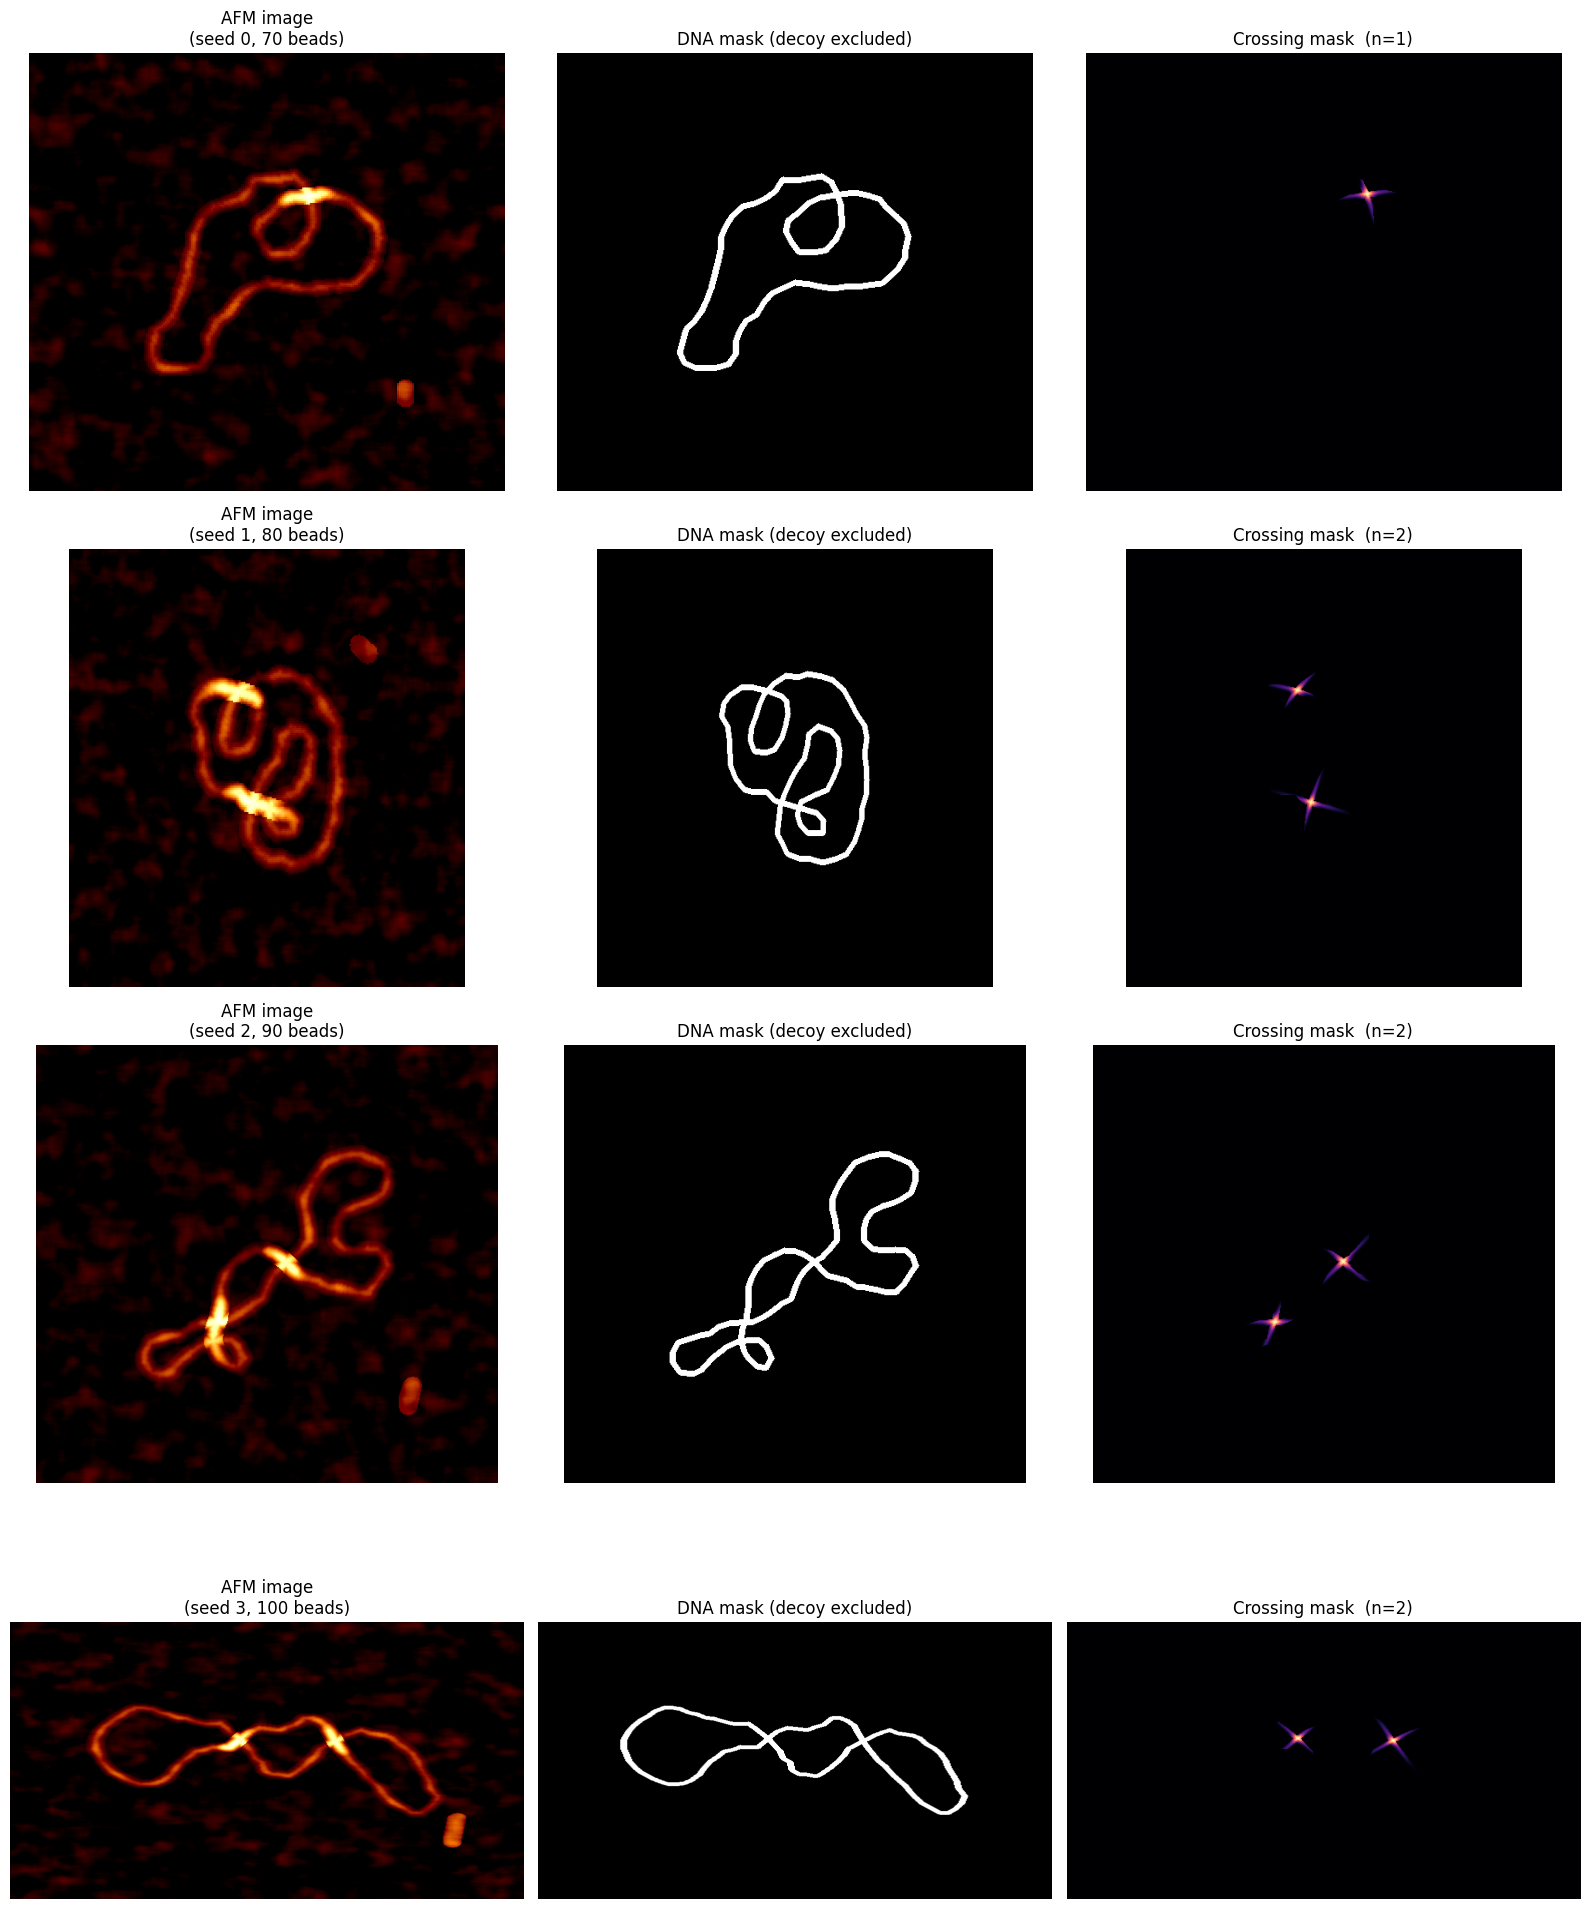

In [36]:
bead_counts = list(BEAD_COUNTS)
seeds       = [int(BASE_SEED + k) for k in range(len(bead_counts))]

samples = [
    generate_one_sample_multilength(
        seeds[i], n_beads=bead_counts[i],
        noise_source=noise_source, noise_asset=noise_asset, add_decoy=True
    )
    for i in range(len(bead_counts))
]

fig, axes = plt.subplots(len(samples), 3, figsize=(16, 5 * len(samples)))

for r, s in enumerate(samples):
    extent = s["extent"]
    img    = s["afm_img"]

    print(f"\n{'='*20} SAMPLE {r+1} (Seed: {s['seed']}, "
          f"{s['n_beads']} beads) {'='*20}")
    print(f"Image window (nm): X=[{extent[0]:.1f}, {extent[1]:.1f}], "
          f"Y=[{extent[2]:.1f}, {extent[3]:.1f}]")

    if s.get("decoy_coords") is not None:
        d = s["decoy_coords"]
        print(f"Decoy XY bounds (nm): "
              f"X=[{d[:,0].min():.1f}, {d[:,0].max():.1f}], "
              f"Y=[{d[:,1].min():.1f}, {d[:,1].max():.1f}]")
        print(f"Decoy Z range (nm):   {d[:,2].min():.2f} – {d[:,2].max():.2f}")
        oob = (d[:,0].min() < extent[0] or d[:,0].max() > extent[1] or
               d[:,1].min() < extent[2] or d[:,1].max() > extent[3])
        print(" Decoy out-of-bounds!" if oob else "Decoy inside extent.")
        if d[:,2].max() < 0.1:
            print(" Decoy height ≈ 0")

    ax1, ax2, ax3 = axes[r]
    ext_list = list(extent)

    ax1.imshow(img,           cmap="afmhot", origin="lower", extent=ext_list)
    ax1.set_title(f"AFM image\n(seed {s['seed']}, {s['n_beads']} beads)")
    ax1.axis("off")

    ax2.imshow(s["dna_mask"], cmap="gray",   origin="lower", extent=ext_list)
    ax2.set_title("DNA mask (decoy excluded)")
    ax2.axis("off")

    ax3.imshow(s["cross_mask"], cmap="magma", origin="lower", extent=ext_list)
    ax3.set_title(f"Crossing mask  (n={s['n_crossings']})")
    ax3.axis("off")

plt.tight_layout()
plt.show()

##13. Benchmarking

We also provide the option to benchmark the performance of the pipeline and to see estimates on how long it might take to generate the required amount of samples. This can be very useful to compare which system might be optimal for production of the dataset and how GPU acceleration can be used to improve the time needed for dataset generation.

In [37]:
# ─────────────────────────────────────────────────────────────────────────────
## Cell B — Single-Sample Benchmark
# ─────────────────────────────────────────────────────────────────────────────

import time
import tracemalloc
import os
import platform
import psutil
import threading
import statistics

# ── Helper: peak RSS tracker ──────
class _PeakMemTracker:
    def __init__(self):
        self._proc   = psutil.Process(os.getpid())
        self.peak_mb = 0.0
        self._stop   = threading.Event()

    def _run(self):
        while not self._stop.is_set():
            try:
                rss = self._proc.memory_info().rss / 1e6
                if rss > self.peak_mb:
                    self.peak_mb = rss
            except Exception: pass
            self._stop.wait(0.05)

    def start(self):
        self._t = threading.Thread(target=self._run, daemon=True)
        self._t.start()

    def stop(self):
        self._stop.set(); self._t.join()

# ── System Info ──
cpu_logical  = psutil.cpu_count(logical=True)

# Fix: Identify available platforms instead of calling non-existent getDefaultPlatform
platforms = [openmm.Platform.getPlatform(i).getName() for i in range(openmm.Platform.getNumPlatforms())]
active_platform = "OpenCL" if "OpenCL" in platforms else "CPU"

print("=" * 62)
print("  SYSTEM PROFILE")
print("=" * 62)
print(f"  OS              : {platform.system()} {platform.release()}")
print(f"  CPU (logical)   : {cpu_logical} cores")
print(f"  RAM available   : {psutil.virtual_memory().available / 1e9:.1f} GB")
print(f"  OpenMM Platforms: {platforms}")
print(f"  Benchmarking on : {active_platform}")
print()

BENCH_SEED    = int(BASE_SEED)
BENCH_N_BEADS = int(BEAD_COUNTS[0])
BENCH_REPS    = 3

def _bench_stages(seed, n_beads):
    t = {}
    t0 = time.perf_counter()
    coords0 = make_tangled_ring_initial(seed, n_beads=n_beads)
    t["1_chain_init"] = time.perf_counter() - t0

    t0 = time.perf_counter()
    frames = run_md_relaxation(coords0, seed=seed, n_frames=N_FRAMES, steps_per_frame=STEPS_PER_FRAME)
    t["2_md_relax"] = time.perf_counter() - t0

    last_coords = frames[-1]
    t0 = time.perf_counter()
    crossings = find_polyline_crossings(last_coords[:, :2])
    t["3_crossing_detect"] = time.perf_counter() - t0

    t0 = time.perf_counter()
    chain = dict(seed=seed, n_beads=n_beads, coords=last_coords, crossings=crossings)
    render_chain_and_masks(chain, noise_source="none", noise_asset=None)
    t["4_afm_render_masks"] = time.perf_counter() - t0
    return t

print("=" * 62)
print("  RUNNING BENCHMARK")
print("=" * 62)

wall_times = []
mem_tracker = _PeakMemTracker()
mem_tracker.start()

for rep in range(BENCH_REPS):
    t0 = time.perf_counter()
    _ = _bench_stages(BENCH_SEED + rep, BENCH_N_BEADS)
    elapsed = time.perf_counter() - t0
    wall_times.append(elapsed)
    print(f"  Rep {rep+1}/{BENCH_REPS}: {elapsed:.2f}s")

mem_tracker.stop()
med_wall = statistics.median(wall_times)
total_samples = int(N_SAMPLES) * len(BEAD_COUNTS)
est_hours = (med_wall * total_samples) / 3600

print("=" * 62)
print(f"  Median Wall Time: {med_wall:.2f} s")
print(f"  Peak RAM (RSS)  : {mem_tracker.peak_mb:.1f} MB")
print(f"  Projected Total : {est_hours:.1f} hours for {total_samples} samples")
print("=" * 62)


  SYSTEM PROFILE
  OS              : Linux 6.6.113+
  CPU (logical)   : 2 cores
  RAM available   : 11.5 GB
  OpenMM Platforms: ['Reference', 'CPU', 'CUDA', 'OpenCL']
  Benchmarking on : OpenCL

  RUNNING BENCHMARK
Using OpenCL platform.
  Rep 1/3: 6.06s
Using OpenCL platform.
  Rep 2/3: 4.27s
Using OpenCL platform.
  Rep 3/3: 3.29s
  Median Wall Time: 4.27 s
  Peak RAM (RSS)  : 794.2 MB
  Projected Total : 4.7 hours for 4000 samples


## 14.Dataset Generation

Finally, we are ready to generate the full dataset. The amount of samples and the lenghts of the chains is defined in the global variables and will be referenced here.
This notebook generates the full dataset (default: 1000 samples × 4 chain lengths).


Progress is printed every 10 samples and a `manifest.csv` tracks all file paths.

In [ ]:
manifest_path = os.path.join(OUT_DIR, "manifest.csv")
print(f"Starting dataset generation: {N_SAMPLES} samples…")

with open(manifest_path, "w", newline="") as f:
    w = csv.writer(f)
    w.writerow(["index", "seed", "image_npy", "dna_mask_npy",
                "cross_mask_npy", "meta_npz", "n_crossings", "has_decoy"])

    for idx in range(int(N_SAMPLES)):
        # Seed override for a known-problematic sample
        if idx == 832:
            seed = int(BASE_SEED + idx + 9997)
            print(f"Special override for index 832: seed = {seed}")
        else:
            seed = int(BASE_SEED + idx)

        n_beads      = int(BEAD_COUNTS[idx % len(BEAD_COUNTS)])
        add_decoy    = (idx % 5 == 0)

        s = generate_one_sample_multilength(
            seed, n_beads=n_beads,
            noise_source=noise_source,
            noise_asset=noise_asset,
            add_decoy=add_decoy,
        )

        img_path   = os.path.join("images",      f"img_{idx:04d}.npy")
        dna_path   = os.path.join("dna_masks",   f"dna_{idx:04d}.npy")
        cross_path = os.path.join("cross_masks", f"cross_{idx:04d}.npy")
        meta_path  = os.path.join("meta",        f"meta_{idx:04d}.npz")

        np.save(os.path.join(OUT_DIR, img_path),   s["afm_img"])
        np.save(os.path.join(OUT_DIR, dna_path),   s["dna_mask"])
        np.save(os.path.join(OUT_DIR, cross_path), s["cross_mask"])
        np.savez_compressed(
            os.path.join(OUT_DIR, meta_path),
            seed       = s["seed"],
            n_beads    = int(s["n_beads"]),
            extent     = s["extent"],
            n_crossings= s["n_crossings"],
            has_decoy  = add_decoy,
        )

        w.writerow([idx, seed, img_path, dna_path,
                    cross_path, meta_path,
                    s["n_crossings"], add_decoy])

        if (idx + 1) % 10 == 0:
            print(f"Progress: {idx+1}/{N_SAMPLES}")

print("\nDone.  Dataset written to:", OUT_DIR)
print("Manifest:", manifest_path)